# Stage 4 Sleep Stress Linear Models

Linear-family experiments for next-sleep average stress using the Stage 4 day-to-next-sleep modeling frame.


In [39]:
from dataclasses import replace
from pathlib import Path
import importlib
import os
import sys
import warnings

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/wearable-analytics-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import exceptions as sklearn_exceptions

convergence_warning = getattr(sklearn_exceptions, "Convergence" + "Warning")
warnings.filterwarnings("ignore", category=convergence_warning)

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from garmin_analytics.modeling.stage4 import STAGE4_PRIMARY_TARGET, STAGE4_SPLIT_COLUMN, split_summary
import garmin_analytics.modeling.stage4_linear as stage4_linear

stage4_linear = importlib.reload(stage4_linear)
Stage4LinearConfig = stage4_linear.Stage4LinearConfig
Stage4LinearGridSpec = stage4_linear.Stage4LinearGridSpec
build_stage4_linear_candidate_grid = stage4_linear.build_stage4_linear_candidate_grid
build_stage4_linear_best_by_model_family_artifact = stage4_linear.build_stage4_linear_best_by_model_family_artifact
build_stage4_linear_experiment_plan = stage4_linear.build_stage4_linear_experiment_plan
build_stage4_linear_summary_markdown = stage4_linear.build_stage4_linear_summary_markdown
finalize_stage4_linear_modeling = stage4_linear.finalize_stage4_linear_modeling
evaluate_stage4_linear_contiguous_dev_diagnostic = stage4_linear.evaluate_stage4_linear_contiguous_dev_diagnostic
format_stage4_linear_experiment_plan = stage4_linear.format_stage4_linear_experiment_plan
candidate_grid_frame = stage4_linear.candidate_grid_frame
compute_stage4_linear_feature_importance = stage4_linear.compute_stage4_linear_feature_importance
plot_stage4_linear_prediction_diagnostics = stage4_linear.plot_stage4_linear_prediction_diagnostics
plot_stage4_linear_rank1_feature_importance = stage4_linear.plot_stage4_linear_rank1_feature_importance
plot_stage4_linear_hyperparameter_diagnostics = stage4_linear.plot_stage4_linear_hyperparameter_diagnostics
plot_stage4_linear_factor_comparisons = stage4_linear.plot_stage4_linear_factor_comparisons
plot_stage4_linear_finalist_metric_comparison = stage4_linear.plot_stage4_linear_finalist_metric_comparison
plot_stage4_linear_mixed_validation_family_comparison = stage4_linear.plot_stage4_linear_mixed_validation_family_comparison
plot_stage4_linear_validation_diagnostics = stage4_linear.plot_stage4_linear_validation_diagnostics
resolve_stage4_feature_columns = stage4_linear.resolve_stage4_feature_columns
refresh_stage4_linear_tuning_result_summaries = stage4_linear.refresh_stage4_linear_tuning_result_summaries
run_stage4_linear_modeling = stage4_linear.run_stage4_linear_modeling
stage4_linear_grid_spec_from_preset = stage4_linear.stage4_linear_grid_spec_from_preset
stage4_linear_experiment_budget_issues = stage4_linear.stage4_linear_experiment_budget_issues
stage4_linear_candidate_from_record = stage4_linear.stage4_linear_candidate_from_record
select_stage4_linear_future_test_candidates = stage4_linear.select_stage4_linear_future_test_candidates
tune_stage4_linear_modeling = stage4_linear.tune_stage4_linear_modeling

frame_path = repo_root / "data" / "processed" / "stage4_sleep_modeling_frame.parquet"
feature_catalog_path = repo_root / "reports" / "stage4_sleep_modeling_feature_sets.csv"
summary_path = repo_root / "reports" / "stage4_sleep_stress_linear_models_summary.md"
leaderboard_path = repo_root / "reports" / "stage4_sleep_stress_linear_model_leaderboard.csv"
grid_path = repo_root / "reports" / "stage4_sleep_stress_linear_model_grid.csv"
diagnostic_figure_path = repo_root / "docs" / "img" / "stage4_linear_prediction_diagnostics.png"
feature_importance_path = repo_root / "reports" / "stage4_sleep_stress_linear_rank1_feature_importance.csv"
feature_importance_figure_path = repo_root / "docs" / "img" / "stage4_linear_feature_importance.png"
best_by_model_family_path = repo_root / "reports" / "stage4_sleep_stress_linear_best_by_model_family.csv"
for required_path in [frame_path, feature_catalog_path]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("repo_root:", repo_root)


repo_root: /Users/abatrakov/Documents/FUN/wearable-analytics


## Control Panel

This notebook implements a two-stage validation experiment:

1. Tune the full candidate grid on a bounded mix of random and expanding temporal holdouts.
2. Inspect the complete-grid validation diagnostics, then rerank a representative shortlist on more holdouts.
3. Select the global leader and model-family representatives from the rerank only.
4. Refit those validation-selected candidates on all `dev` rows and open the reserved future `test` block once.

`BASELINE_STRATEGY` is selected before the future test is opened. Other dummy baselines are shown only as diagnostic readouts and cannot replace it after seeing test performance.


In [40]:
TARGET_COL = STAGE4_PRIMARY_TARGET
FEATURE_SET_OPTIONS = [
    "aggregate_stage3_baseline",
    "monitoring_core_wake_pre_sleep",
    "monitoring_full_wake_pre_sleep",
    "monitoring_full_wake_pre_sleep_plus_prev_sleep",
    "monitoring_full_wake_pre_sleep_plus_history",
    "monitoring_full_wake_pre_sleep_plus_state",
    "aggregate_plus_monitoring_full",
    "monitoring_full_wake_pre_sleep_plus_state_plus_aggregate",
]
FEATURE_SET = "monitoring_full_wake_pre_sleep_plus_state"
INCLUDE_SCHEDULE_CONTEXT = True
GRID_SOURCE = "control_panel"  # preset, control_panel
GRID_PRESET = "standard"  # smoke, standard, heavy; used only when GRID_SOURCE == "preset"
TUNING_METRIC = "mae"
HOLDOUT_STRATEGY = "mixed"  # random, mixed
REPEATED_HOLDOUT_REPEATS = 3
REPEATED_HOLDOUT_SEED = 42
TEMPORAL_HOLDOUT_REPEATS = 3
TEMPORAL_VALIDATION_ROWS = 45
BASELINE_STRATEGY = "dummy_median"
SHORTLIST_COUNT = 150
SHORTLIST_GLOBAL_TOP_N = 50
SHORTLIST_TEMPORAL_MEAN_TOP_N = 10
SHORTLIST_TEMPORAL_WORST_TOP_N = 10
SHORTLIST_RANDOM_STABILITY_TOP_N = 5
SHORTLIST_MODEL_FAMILY_TOP_N = 5
SHORTLIST_SELECTOR_TOP_N = 1
SHORTLIST_TARGET_TRANSFORM_TOP_N = 5
SHORTLIST_CALIBRATION_TOP_N = 3
SHORTLIST_MIN_BASELINE_WINS = 2
SHORTLIST_TEMPORAL_WORST_RELATIVE_MAE_MAX = 1.25
COMBINED_TEMPORAL_MEAN_WEIGHT = 0.65
COMBINED_TEMPORAL_WORST_WEIGHT = 0.20
COMBINED_RANDOM_MEAN_WEIGHT = 0.10
COMBINED_RANDOM_STABILITY_WEIGHT = 0.05
RUN_SHORTLIST_RERANK = True
SHORTLIST_RERANK_RANDOM_HOLDOUTS = 10
SHORTLIST_RERANK_TEMPORAL_HOLDOUTS = 8
SHORTLIST_RERANK_TEMPORAL_VALIDATION_ROWS = 30
INITIAL_DIAGNOSTIC_TOP_PER_MODEL_FAMILY = 5
FUTURE_TEST_GLOBAL_TOP_N = 1
FUTURE_TEST_MODEL_FAMILY_TOP_N = 1
N_JOBS = 8
PARALLEL_BACKEND = "loky"
PARALLEL_BATCH_SIZE = "auto"
ALLOW_LARGE_GRID_RUN = True
MAX_CANDIDATES_WITHOUT_CONFIRMATION = 30_000
MAX_APPROXIMATE_TUNING_FITS_WITHOUT_CONFIRMATION = 150_000

ENABLED_MODEL_FAMILIES = {
    "linear": True,
    "ridge": True,
    "lasso": True,
    "elastic_net": True,
    "huber": True,
    "pls": True,
}

ENABLED_FEATURE_SELECTION_MODES = {
    "none": True,
    "top_spearman": True,
    "top_mutual_info": True,
    "correlation_prune": True,
    "spearman_then_correlation": True,
    "lasso_nonzero": True,
}

TOP_K_VALUES = [40, 60, 80, 100]#[40, 50, 60, 70, 80, 90, 100]
MIN_FEATURES = 8
MIN_ABS_SPEARMAN_VALUES = [0.0]
MIN_MUTUAL_INFO_VALUES = [0.0]
CORRELATION_THRESHOLDS = [0.90, 0.95, 0.99]
LASSO_SELECTOR_ALPHAS = [0.01, 0.03, 0.1]
LASSO_SELECTOR_MAX_ITER = 50_000

AVAILABLE_ROBUST_CLIPS = ["none", "z=4", "z=5"]
ROBUST_CLIPS = ["none", "z=4", "z=5"]

AVAILABLE_CALIBRATIONS = ["none", "linear"]
CALIBRATIONS = ["none", "linear"]

AVAILABLE_TARGET_TRANSFORMS = ["none", "log1p"]
TARGET_TRANSFORMS = ["none", "log1p"]
AVAILABLE_PREDICTION_CLIPS = ["0_100", "none"]
PREDICTION_CLIPS = ["0_100"]

RIDGE_ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 30.0, 100.0, 300.0, 1000.0] #[0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
LASSO_ALPHAS = [0.0001, 0.001, 0.003, 0.01, 0.03, 0.1, 1.0] #[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
ELASTIC_NET_ALPHAS = [0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0] #[0.0001, 0.0003, 0.001, 0.003, 0.010, 0.030, 0.100, 0.300, 1.000, 3.000]
ELASTIC_NET_L1_RATIOS = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 0.90, 0.95] #[0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
HUBER_ALPHAS = [0.0001, 0.001, 0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0] #[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
HUBER_EPSILONS = [1.05, 1.1, 1.15, 1.2, 1.3, 1.5, 1.75, 2.0] #[1.05, 1.1, 1.15, 1.2, 1.3, 1.4, 1.5, 1.75, 2.0]
PLS_COMPONENTS = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20]
FIT_INTERCEPT = True
MODEL_MAX_ITER = 500_000
MODEL_TOL = 1e-4

CALIBRATION_CV_FOLDS = 3
CALIBRATION_MIN_ROWS = 50


## Data Snapshot


In [41]:
frame = pd.read_parquet(frame_path)
feature_catalog = pd.read_csv(feature_catalog_path)

display(
    pd.DataFrame(
        [
            {
                "rows": len(frame),
                "columns": frame.shape[1],
                "start_date": pd.to_datetime(frame["calendarDate"]).min().date(),
                "end_date": pd.to_datetime(frame["calendarDate"]).max().date(),
                "target_available": int(pd.to_numeric(frame[TARGET_COL], errors="coerce").notna().sum()),
            }
        ]
    )
)
display(split_summary(frame))
display(
    feature_catalog.groupby("feature_set", as_index=False)
    .agg(features=("feature", "nunique"), median_missing_pct=("modeling_missing_pct", "median"))
    .sort_values("feature_set")
)


,rows,columns,start_date,end_date,target_available
0,589,324,2023-05-27,2026-05-18,524


,split,rows,eligible_rows,primary_target_rows,start_date,end_date
0,train,330,330,330,2023-05-27,2026-01-28
1,valid,71,71,71,2023-06-12,2026-01-20
2,test,71,71,71,2026-01-29,2026-05-13
3,not_eligible_or_missing_target,117,0,52,2023-07-10,2026-05-18


,feature_set,features,median_missing_pct
0,aggregate_plus_monitoring_full,138,0.0
1,aggregate_stage3_baseline,33,0.0
2,monitoring_core_wake_pre_sleep,56,0.0
3,monitoring_full_wake_pre_sleep,123,0.0
4,monitoring_full_wake_pre_sleep_plus_history,133,0.0
5,monitoring_full_wake_pre_sleep_plus_prev_sleep,133,0.0
6,monitoring_full_wake_pre_sleep_plus_state,148,0.0
7,monitoring_full_wake_pre_sleep_plus_state_plus...,180,0.0


## Grid Audit


In [42]:
enabled_model_kinds = tuple(kind for kind, enabled in ENABLED_MODEL_FAMILIES.items() if enabled)
enabled_feature_selection_modes = tuple(
    mode for mode, enabled in ENABLED_FEATURE_SELECTION_MODES.items() if enabled
)

if GRID_SOURCE not in {"preset", "control_panel"}:
    raise ValueError("GRID_SOURCE must be 'preset' or 'control_panel'")

config = Stage4LinearConfig(
    target_col=TARGET_COL,
    feature_set=FEATURE_SET,
    grid_source=GRID_SOURCE,
    grid_preset=GRID_PRESET,
    include_schedule_context=INCLUDE_SCHEDULE_CONTEXT,
    repeated_holdout_repeats=REPEATED_HOLDOUT_REPEATS,
    repeated_holdout_seed=REPEATED_HOLDOUT_SEED,
    holdout_strategy=HOLDOUT_STRATEGY,
    temporal_holdout_repeats=TEMPORAL_HOLDOUT_REPEATS,
    temporal_validation_rows=TEMPORAL_VALIDATION_ROWS,
    baseline_strategy=BASELINE_STRATEGY,
    shortlist_count=SHORTLIST_COUNT,
    shortlist_global_top_n=SHORTLIST_GLOBAL_TOP_N,
    shortlist_temporal_mean_top_n=SHORTLIST_TEMPORAL_MEAN_TOP_N,
    shortlist_temporal_worst_top_n=SHORTLIST_TEMPORAL_WORST_TOP_N,
    shortlist_random_stability_top_n=SHORTLIST_RANDOM_STABILITY_TOP_N,
    shortlist_model_family_top_n=SHORTLIST_MODEL_FAMILY_TOP_N,
    shortlist_selector_top_n=SHORTLIST_SELECTOR_TOP_N,
    shortlist_target_transform_top_n=SHORTLIST_TARGET_TRANSFORM_TOP_N,
    shortlist_calibration_top_n=SHORTLIST_CALIBRATION_TOP_N,
    shortlist_min_baseline_wins=SHORTLIST_MIN_BASELINE_WINS,
    shortlist_temporal_worst_relative_mae_max=SHORTLIST_TEMPORAL_WORST_RELATIVE_MAE_MAX,
    combined_temporal_mean_weight=COMBINED_TEMPORAL_MEAN_WEIGHT,
    combined_temporal_worst_weight=COMBINED_TEMPORAL_WORST_WEIGHT,
    combined_random_mean_weight=COMBINED_RANDOM_MEAN_WEIGHT,
    combined_random_stability_weight=COMBINED_RANDOM_STABILITY_WEIGHT,
    tuning_metric=TUNING_METRIC,
    calibration_cv_folds=CALIBRATION_CV_FOLDS,
    calibration_min_rows=CALIBRATION_MIN_ROWS,
    finalist_count=0,  # Explicit validation-selected ids are passed at finalization.
    n_jobs=N_JOBS,
    parallel_backend=PARALLEL_BACKEND,
    parallel_batch_size=PARALLEL_BATCH_SIZE,
)

if GRID_SOURCE == "preset":
    grid_spec = stage4_linear_grid_spec_from_preset(GRID_PRESET)
else:
    grid_spec = Stage4LinearGridSpec(
        preset="control_panel",
        model_kinds=enabled_model_kinds,
        feature_selection_modes=enabled_feature_selection_modes,
        top_k_values=tuple(TOP_K_VALUES),
        min_features=MIN_FEATURES,
        min_abs_spearman_values=tuple(MIN_ABS_SPEARMAN_VALUES),
        min_mutual_info_values=tuple(MIN_MUTUAL_INFO_VALUES),
        correlation_thresholds=tuple(CORRELATION_THRESHOLDS),
        lasso_selector_alphas=tuple(LASSO_SELECTOR_ALPHAS),
        lasso_selector_max_iter=LASSO_SELECTOR_MAX_ITER,
        robust_clips=tuple(ROBUST_CLIPS),
        calibrations=tuple(CALIBRATIONS),
        target_transforms=tuple(TARGET_TRANSFORMS),
        prediction_clips=tuple(PREDICTION_CLIPS),
        ridge_alphas=tuple(RIDGE_ALPHAS),
        lasso_alphas=tuple(LASSO_ALPHAS),
        elastic_net_alphas=tuple(ELASTIC_NET_ALPHAS),
        elastic_net_l1_ratios=tuple(ELASTIC_NET_L1_RATIOS),
        huber_alphas=tuple(HUBER_ALPHAS),
        huber_epsilons=tuple(HUBER_EPSILONS),
        pls_components=tuple(PLS_COMPONENTS),
        fit_intercept=FIT_INTERCEPT,
        max_iter=MODEL_MAX_ITER,
        tol=MODEL_TOL,
    )

feature_columns = resolve_stage4_feature_columns(
    feature_catalog,
    feature_set=FEATURE_SET,
    include_schedule_context=INCLUDE_SCHEDULE_CONTEXT,
)
candidates = build_stage4_linear_candidate_grid(config, grid_spec)
grid_audit = candidate_grid_frame(candidates)
experiment_plan = build_stage4_linear_experiment_plan(
    config,
    candidates,
    feature_columns=feature_columns,
)
experiment_budget_issues = stage4_linear_experiment_budget_issues(
    experiment_plan,
    max_candidates=MAX_CANDIDATES_WITHOUT_CONFIRMATION,
    max_approximate_tuning_fits=MAX_APPROXIMATE_TUNING_FITS_WITHOUT_CONFIRMATION,
)

print(format_stage4_linear_experiment_plan(experiment_plan))
if experiment_budget_issues:
    print("\nTuning safety check: explicit confirmation required")
    for issue in experiment_budget_issues:
        print(f"  - {issue}")
    print("  Set ALLOW_LARGE_GRID_RUN = True only if this expanded run is intentional.")
else:
    print("\nTuning safety check: within configured budget")
display(
    grid_audit.groupby(["model_kind", "feature_selection_mode"], as_index=False)
    .size()
    .rename(columns={"size": "candidates"})
)


Experiment plan

Target:
  target_col: target_avgSleepStress_next_sleep

Feature set:
  feature_set: monitoring_full_wake_pre_sleep_plus_state
  include_schedule_context: True
  candidate_features: 148

Grid source:
  grid_source: control_panel
  grid_preset: not used

Validation:
  metric: mae
  holdout_strategy: mixed
  repeated_holdout_repeats: 3
  temporal_holdout_repeats: 3
  tuning_holdout_count: 6
  temporal_validation_rows: 45
  baseline_strategy: dummy_median
  repeated_holdout_seed: 42

Enabled preprocessing:
  robust_clips: ['none', 'z=4', 'z=5']  count=3
  target_transforms: ['none', 'log1p']  count=2
  prediction_clips: ['0_100']  count=1
  calibrations: ['none', 'linear']  count=2
  calibration_cv_folds: 3

Feature selection:
  enabled modes:
    none: 1
    top_spearman: 4
    top_mutual_info: 4
    correlation_prune: 3
    spearman_then_correlation: 12
    lasso_nonzero: 3
  total feature selector configs: 27

Model configs:
  linear: 1
  ridge: 9
  lasso: 7
  elastic_n

,model_kind,feature_selection_mode,candidates
0,elastic_net,correlation_prune,2268
1,elastic_net,lasso_nonzero,2268
2,elastic_net,none,756
3,elastic_net,spearman_then_correlation,9072
4,elastic_net,top_mutual_info,3024
5,elastic_net,top_spearman,3024
6,huber,correlation_prune,2592
7,huber,lasso_nonzero,2592
8,huber,none,864
9,huber,spearman_then_correlation,10368


## Stage 1: Tune The Full Candidate Grid

The full grid is evaluated without touching the reserved future test. In mixed mode, every candidate receives random-holdout and expanding-temporal-holdout evaluations.


In [43]:
if "experiment_budget_issues" not in globals():
    raise RuntimeError("Run the Grid Audit cell before tuning.")
if experiment_budget_issues and not ALLOW_LARGE_GRID_RUN:
    details = "\n".join(f"- {issue}" for issue in experiment_budget_issues)
    raise RuntimeError(
        "Tuning was not started because the grid exceeds the configured safety budget.\n"
        f"{details}\n"
        "Reduce the control-panel grid or set ALLOW_LARGE_GRID_RUN = True for an intentional large run."
    )

import time

def _format_tuning_duration(seconds):
    if seconds is None:
        return "estimating"
    seconds = max(0, int(round(seconds)))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

progress_state = {
    "started": time.perf_counter(),
    "last_render": 0.0,
    "completed": 0,
    "total": int(experiment_plan["split_evaluations"]),
}
progress_handle = display(pd.DataFrame([{"status": "starting"}]), display_id=True)

def update_tuning_progress(completed, total, *, status="running"):
    now = time.perf_counter()
    progress_state["completed"] = completed
    progress_state["total"] = total
    if status == "running" and completed not in {0, total} and now - progress_state["last_render"] < 30.0:
        return
    progress_state["last_render"] = now
    elapsed = now - progress_state["started"]
    rate = completed / elapsed if completed > 0 and elapsed > 0 else 0.0
    remaining = (total - completed) / rate if rate > 0 else None
    percent = 100.0 * completed / total if total else 100.0
    progress_frame = pd.DataFrame(
        [
            {
                "status": status,
                "progress": f"{percent:6.2f}%",
                "completed": f"{completed:,} / {total:,}",
                "elapsed": _format_tuning_duration(elapsed),
                "remaining": _format_tuning_duration(remaining),
                "evaluations_per_second": f"{rate:.2f}" if rate > 0 else "estimating",
            }
        ]
    )
    if progress_handle is not None:
        progress_handle.update(progress_frame)
    else:
        display(progress_frame)

if "tuning_result" in globals():
    del tuning_result
try:
    tuning_result = tune_stage4_linear_modeling(
        frame,
        feature_catalog,
        config=config,
        candidates=candidates,
        progress_callback=update_tuning_progress,
    )
except Exception as exc:
    update_tuning_progress(progress_state["completed"], progress_state["total"], status="failed")
    raise RuntimeError(
        "Candidate tuning failed before tuning_result was created. Fix the error above, then rerun this cell."
    ) from exc

update_tuning_progress(progress_state["total"], progress_state["total"], status="complete")
print("Validation-only tuning complete. The reserved future test has not been evaluated.")
display(
    pd.DataFrame(
        [
            {
                "candidate_features": len(tuning_result.feature_columns),
                "candidate_grid": len(tuning_result.candidate_grid),
                "random_holdouts": config.repeated_holdout_repeats,
                "temporal_holdouts": config.temporal_holdout_repeats if config.holdout_strategy == "mixed" else 0,
                "shortlist_candidates": len(tuning_result.shortlist_summary),
                "candidate_evaluations": len(tuning_result.tuning_repeats),
                "future_test_evaluated": False,
            }
        ]
    )
)


,status,progress,completed,elapsed,remaining,evaluations_per_second
0,complete,100.00%,"316,872 / 316,872",13:03:13,00:00:00,6.74


Validation-only tuning complete. The reserved future test has not been evaluated.


,candidate_features,candidate_grid,random_holdouts,temporal_holdouts,shortlist_candidates,candidate_evaluations,future_test_evaluated
0,148,52812,3,3,150,316872,False


## Stage 1 Validation Leaderboards

All tables in this section come from the initial full-grid run.

- `mean_train_*` and `mean_valid_*` pool all random and temporal holdouts. They are useful summaries, but they are not the primary mixed-validation ranking.
- `random_*` columns summarize interpolation-oriented random holdouts.
- `temporal_*` columns summarize forward-looking expanding temporal holdouts.
- `combined_rank_score` is the primary validation-only ranking and never uses the future test.

The tables are, in order: overall ranking, best candidate per model family, best candidate per model-family/selector pair, dummy validation results, and the representative shortlist selected for Stage 2.


In [44]:
if "tuning_result" not in globals():
    raise RuntimeError(
        "tuning_result is unavailable. Run the Grid Audit cell, then complete the "
        "Tune Candidate Grid On Repeated Validation Holdouts cell before opening leaderboards."
    )

tuning_result = refresh_stage4_linear_tuning_result_summaries(tuning_result)
print("Stored holdout evaluations reaggregated; candidate models were not refit.")

validation_cols = [
    "selection_rank",
    "candidate_short_label",
    "model_kind",
    "model_param_1",
    "model_param_2",
    "feature_selection_mode",
    "feature_selection_config_label",
    "feature_selection_param_1",
    "feature_selection_param_2",
    "robust_clip",
    "calibration",
    "target_transform",
    "prediction_clip",
    "temporal_mean_train_mae",
    "temporal_mean_valid_mae",
    "temporal_mean_relative_mae",
    "temporal_worst_relative_mae",
    "random_mean_train_mae",
    "random_mean_valid_mae",
    "random_mean_relative_mae",
    "random_relative_mae_std",
    "mean_train_mae",
    "mean_valid_mae",
    "std_valid_mae",
    "mean_valid_rmse",
    "mean_valid_r2",
    "mean_valid_spearman",
    "mean_selected_feature_count",
    "random_baseline_wins",
    "temporal_baseline_wins",
    "baseline_gate_pass",
    "combined_rank_score",
]

overall_validation = tuning_result.validation_slices["overall_validation"]
best_by_model = tuning_result.validation_slices["best_by_model_kind"]
best_by_model_selector = tuning_result.validation_slices["best_by_model_kind_feature_selection"]

print("Initial full-grid overall validation ranking")
display(overall_validation[validation_cols].head(100))
print("Initial full-grid best candidate per model family")
display(best_by_model[validation_cols])
print("Initial full-grid best candidate per model-family/selector pair")
display(best_by_model_selector[validation_cols].head(50))
print("Dummy baselines ranked on validation only")
display(
    tuning_result.validation_slices["dummy_validation"][
        [
            "model_kind",
            "temporal_mean_valid_mae",
            "random_mean_valid_mae",
            "mean_valid_mae",
            "std_valid_mae",
        ]
    ]
)


print("Representative shortlist for expanded rerank")
if not tuning_result.shortlist_summary.empty:
    shortlist_cols = [
        "shortlist_rank",
        "candidate_id",
        "candidate_short_label",
        "model_kind",
        "feature_selection_mode",
        "target_transform",
        "calibration",
        "combined_rank_score",
        "temporal_mean_relative_mae",
        "temporal_worst_relative_mae",
        "random_mean_relative_mae",
        "random_relative_mae_std",
        "baseline_gate_pass",
        "shortlist_roles",
        "shortlist_protected",
    ]
    display(tuning_result.shortlist_summary[shortlist_cols])
    display(
        tuning_result.shortlist_summary.groupby("model_kind", as_index=False)
        .size()
        .rename(columns={"size": "shortlist_candidates"})
    )


Stored holdout evaluations reaggregated; candidate models were not refit.
Initial full-grid overall validation ranking


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count,random_baseline_wins,temporal_baseline_wins,baseline_gate_pass,combined_rank_score
0,1,Huber alpha=100 eps=1.05 | top_mutual_info_60 ...,huber,alpha=100,epsilon=1.05,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=4,...,3.769301,0.388012,5.207364,0.329152,0.578186,60.000000,3,3,True,0.043373
1,2,Huber alpha=100 eps=1.05 | top_mutual_info_60 ...,huber,alpha=100,epsilon=1.05,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=5,...,3.779857,0.391597,5.210663,0.327844,0.572086,60.000000,3,3,True,0.049574
2,3,Huber alpha=3 eps=1.05 | spearman_then_correla...,huber,alpha=3,epsilon=1.05,spearman_then_correlation,spearman_then_correlation_80_corr0.9,top_k=80,corr=0.9,z=5,...,3.728023,0.269544,5.197207,0.327631,0.596243,47.833333,3,2,True,0.052243
3,4,Huber alpha=3 eps=1.1 | spearman_then_correlat...,huber,alpha=3,epsilon=1.1,spearman_then_correlation,spearman_then_correlation_80_corr0.95,top_k=80,corr=0.95,z=5,...,3.750199,0.286473,5.211327,0.323815,0.591628,59.500000,3,2,True,0.056764
4,5,Huber alpha=3 eps=1.1 | spearman_then_correlat...,huber,alpha=3,epsilon=1.1,spearman_then_correlation,spearman_then_correlation_80_corr0.95,top_k=80,corr=0.95,none,...,3.779370,0.280173,5.250663,0.314185,0.590931,59.500000,3,2,True,0.059080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Huber alpha=3 eps=1.1 | spearman_then_correlat...,huber,alpha=3,epsilon=1.1,spearman_then_correlation,spearman_then_correlation_80_corr0.99,top_k=80,corr=0.99,z=5,...,3.808083,0.354289,5.239784,0.315635,0.585049,75.666667,3,2,True,0.088672
96,97,Huber alpha=3 eps=1.2 | spearman_then_correlat...,huber,alpha=3,epsilon=1.2,spearman_then_correlation,spearman_then_correlation_80_corr0.9,top_k=80,corr=0.9,none,...,3.780991,0.256119,5.240445,0.312773,0.587162,47.833333,3,2,True,0.088776
97,98,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,alpha=30,epsilon=1.05,correlation_prune,correlation_prune_0.95,corr=0.95,min_features=8,z=4,...,3.744523,0.381065,5.200086,0.324815,0.585130,119.833333,3,2,True,0.088987
98,99,Huber alpha=10 eps=1.1 | top_mutual_info_100 |...,huber,alpha=10,epsilon=1.1,top_mutual_info,top_mutual_info_100,top_k=100,min_features=8,z=5,...,3.816230,0.410523,5.298485,0.302905,0.577619,100.000000,3,2,True,0.089080


Initial full-grid best candidate per model family


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count,random_baseline_wins,temporal_baseline_wins,baseline_gate_pass,combined_rank_score
0,1,Huber alpha=100 eps=1.05 | top_mutual_info_60 ...,huber,alpha=100,epsilon=1.05,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=4,...,3.769301,0.388012,5.207364,0.329152,0.578186,60.000000,3,3,True,0.043373
1,18,PLS k=6 | top_mutual_info_60 | clip=none | cal...,pls,n_components=6,,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,none,...,3.775331,0.356436,5.223605,0.319952,0.590633,60.000000,3,2,True,0.070282
2,38,ElasticNet alpha=0.01 l1=0.7 | correlation_pru...,elastic_net,alpha=0.01,l1_ratio=0.7,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,none,...,3.762835,0.328300,5.194837,0.321460,0.596059,97.833333,3,2,True,0.079255
3,78,Lasso alpha=0.01 | correlation_prune_0.9 | cli...,lasso,alpha=0.01,,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,none,...,3.760046,0.288863,5.191009,0.322321,0.600888,97.833333,3,2,True,0.086662
4,338,Ridge alpha=1 | spearman_then_correlation_100_...,ridge,alpha=1,,spearman_then_correlation,spearman_then_correlation_100_corr0.95,top_k=100,corr=0.95,z=4,...,3.945817,0.414645,5.414037,0.273452,0.582033,76.500000,3,3,True,0.102155
5,558,Linear | spearman_then_correlation_100_corr0.9...,linear,,,spearman_then_correlation,spearman_then_correlation_100_corr0.95,top_k=100,corr=0.95,z=5,...,3.984563,0.461795,5.478059,0.258828,0.576580,76.500000,3,3,True,0.107815


Initial full-grid best candidate per model-family/selector pair


...

Dummy baselines ranked on validation only


,model_kind,temporal_mean_valid_mae,random_mean_valid_mae,mean_valid_mae,std_valid_mae
0,dummy_median,4.746519,4.665329,4.705924,0.710098
1,dummy_mean,4.887338,4.734004,4.810671,0.710092
2,dummy_last,6.974000,4.643991,5.808995,1.658454


Representative shortlist for expanded rerank


,shortlist_rank,candidate_id,candidate_short_label,model_kind,feature_selection_mode,target_transform,calibration,combined_rank_score,temporal_mean_relative_mae,temporal_worst_relative_mae,random_mean_relative_mae,random_relative_mae_std,baseline_gate_pass,shortlist_roles,shortlist_protected
0,1,13469,Huber alpha=100 eps=1.05 | top_mutual_info_60 ...,huber,top_mutual_info,log1p,none,0.043373,0.841317,0.976769,0.778928,0.080007,True,"calibration_representative,global_top,model_fa...",True
1,2,13473,Huber alpha=100 eps=1.05 | top_mutual_info_60 ...,huber,top_mutual_info,log1p,none,0.049574,0.844732,0.986284,0.780544,0.080843,True,"calibration_representative,global_top,model_fa...",True
2,3,36656,Huber alpha=3 eps=1.05 | spearman_then_correla...,huber,spearman_then_correlation,none,none,0.052243,0.833030,1.008586,0.776126,0.077888,True,"calibration_representative,global_top,model_fa...",True
3,4,38624,Huber alpha=3 eps=1.1 | spearman_then_correlat...,huber,spearman_then_correlation,none,none,0.056764,0.839838,1.018372,0.778464,0.075150,True,"global_top,model_family_representative,target_...",True
4,5,38616,Huber alpha=3 eps=1.1 | spearman_then_correlat...,huber,spearman_then_correlation,none,none,0.059080,0.846907,1.026499,0.783565,0.065672,True,"global_top,model_family_representative,target_...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,22947,Huber alpha=1 eps=2 | correlation_prune_0.99 |...,huber,correlation_prune,log1p,linear,0.325045,0.914006,0.950672,0.953451,0.002061,True,random_stability_leader,False
146,147,22707,Huber alpha=0.01 eps=1.2 | correlation_prune_0...,huber,correlation_prune,log1p,linear,0.438514,0.933859,0.952748,0.966836,0.002098,True,random_stability_leader,False
147,148,22611,Huber alpha=0.001 eps=1.2 | correlation_prune_...,huber,correlation_prune,log1p,linear,0.446677,0.935183,0.957642,0.967178,0.002352,True,random_stability_leader,False
148,149,1299,Huber alpha=0.1 eps=1.3 | none | clip=none | c...,huber,none,log1p,linear,0.464299,0.937973,0.965397,0.969578,0.002360,True,random_stability_leader,False


,model_kind,shortlist_candidates
0,elastic_net,11
1,huber,116
2,lasso,5
3,linear,5
4,pls,8
5,ridge,5


## Stage 1 Validation-Only Diagnostics

These diagnostics describe the complete initial grid before shortlist reranking. Temporal mean validation MAE is the primary metric for rankings, hyperparameter heatmaps, feature-selector comparisons, and clipping comparisons.

Random holdouts are retained only where they answer a separate question: how interpolation performance differs from temporal performance, how sensitive candidates are to random sample composition, and whether model-family conclusions change between holdout types. The reserved future test remains unopened.


validation_mae_distribution


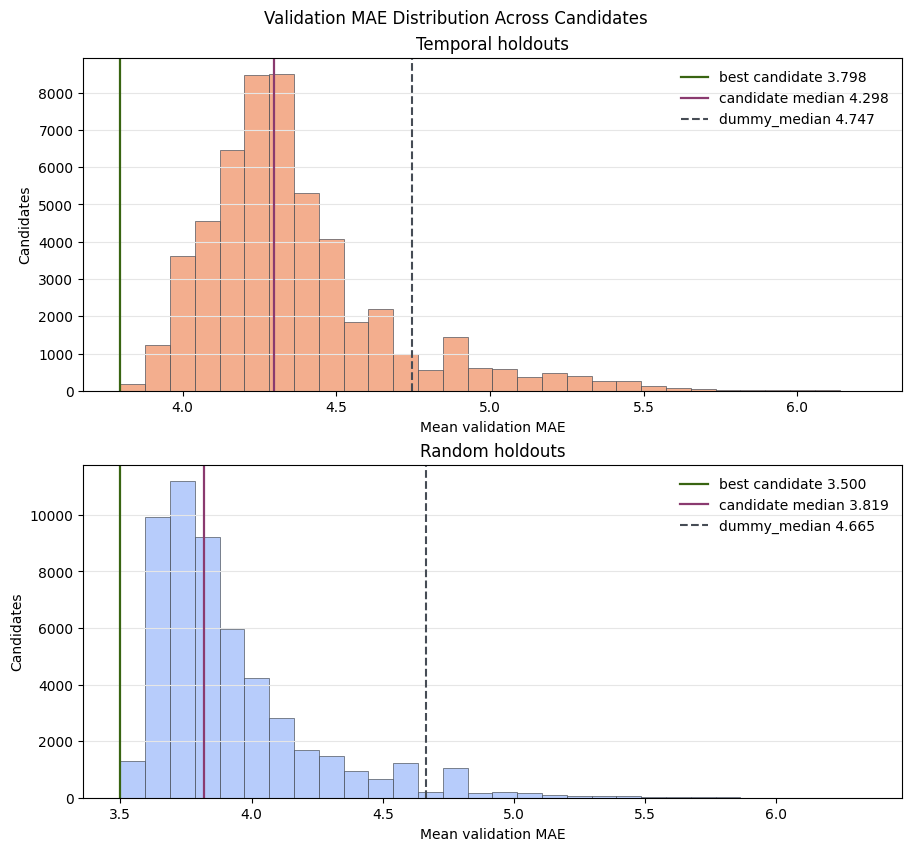

top_candidates


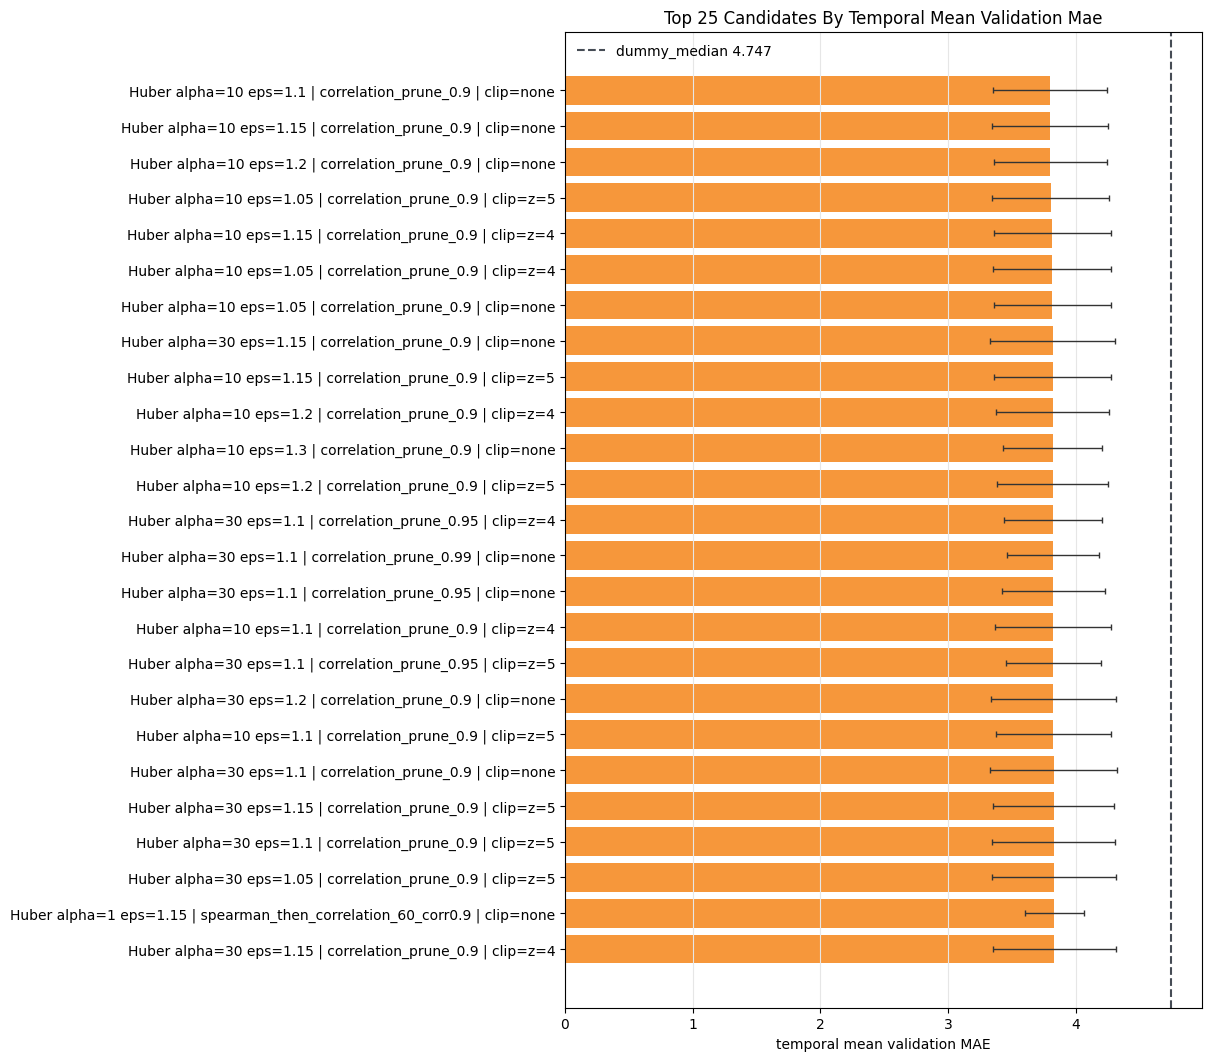

top_candidates_by_model_family


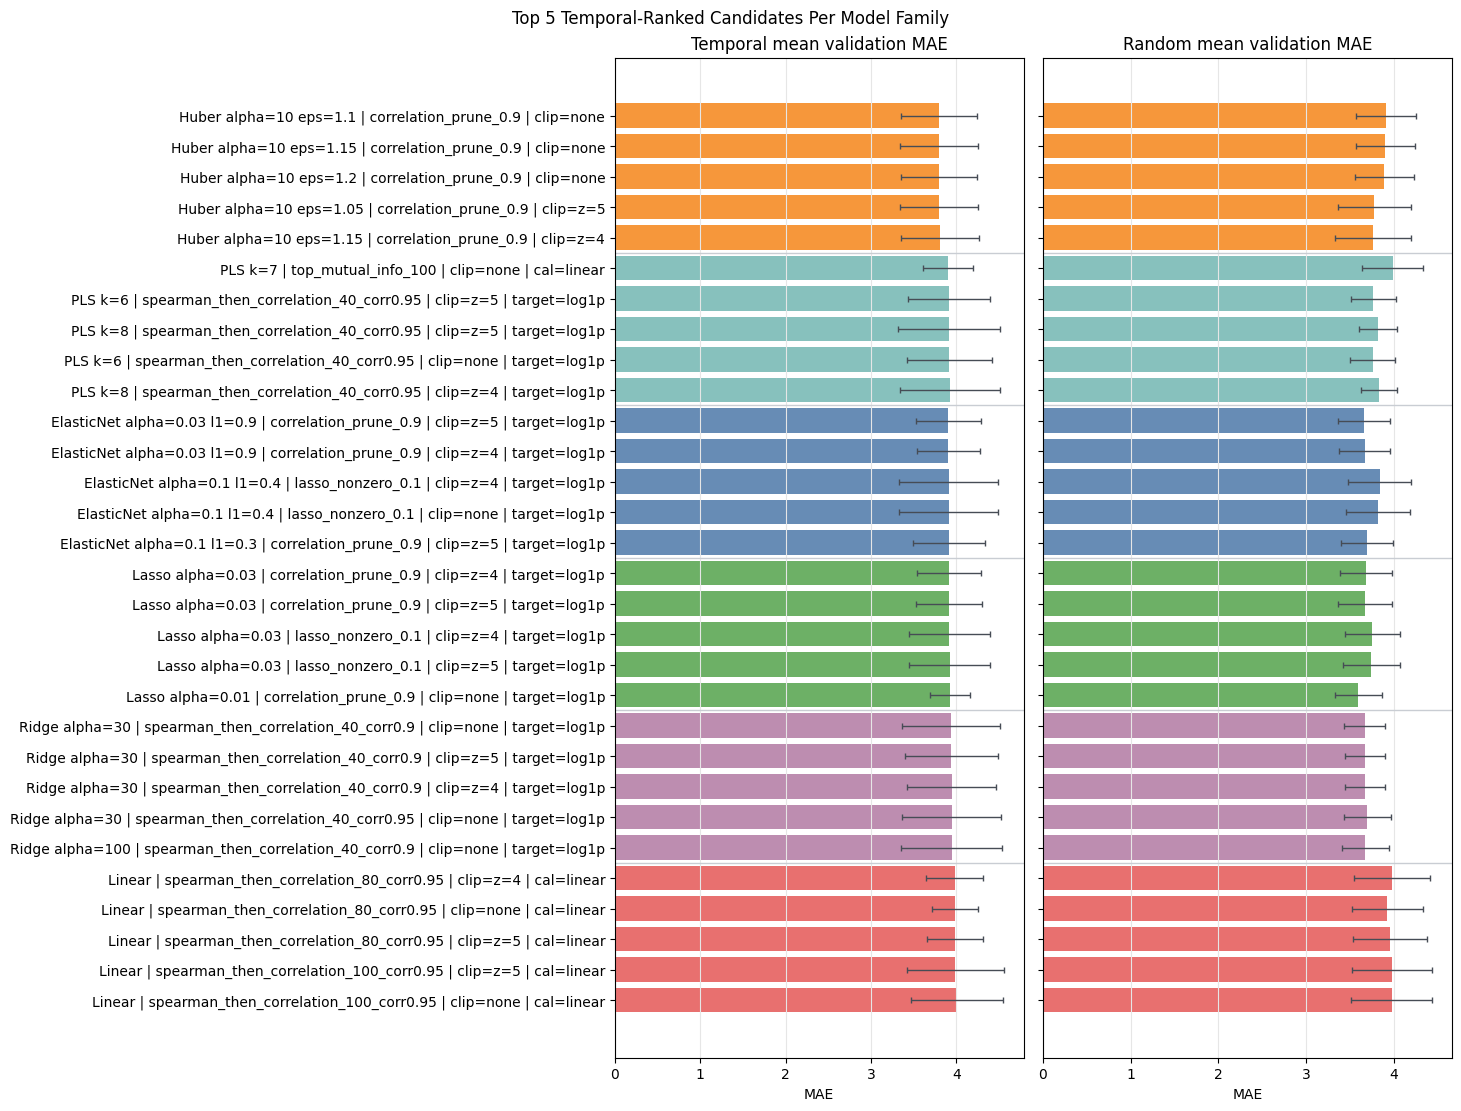

best_by_model_family


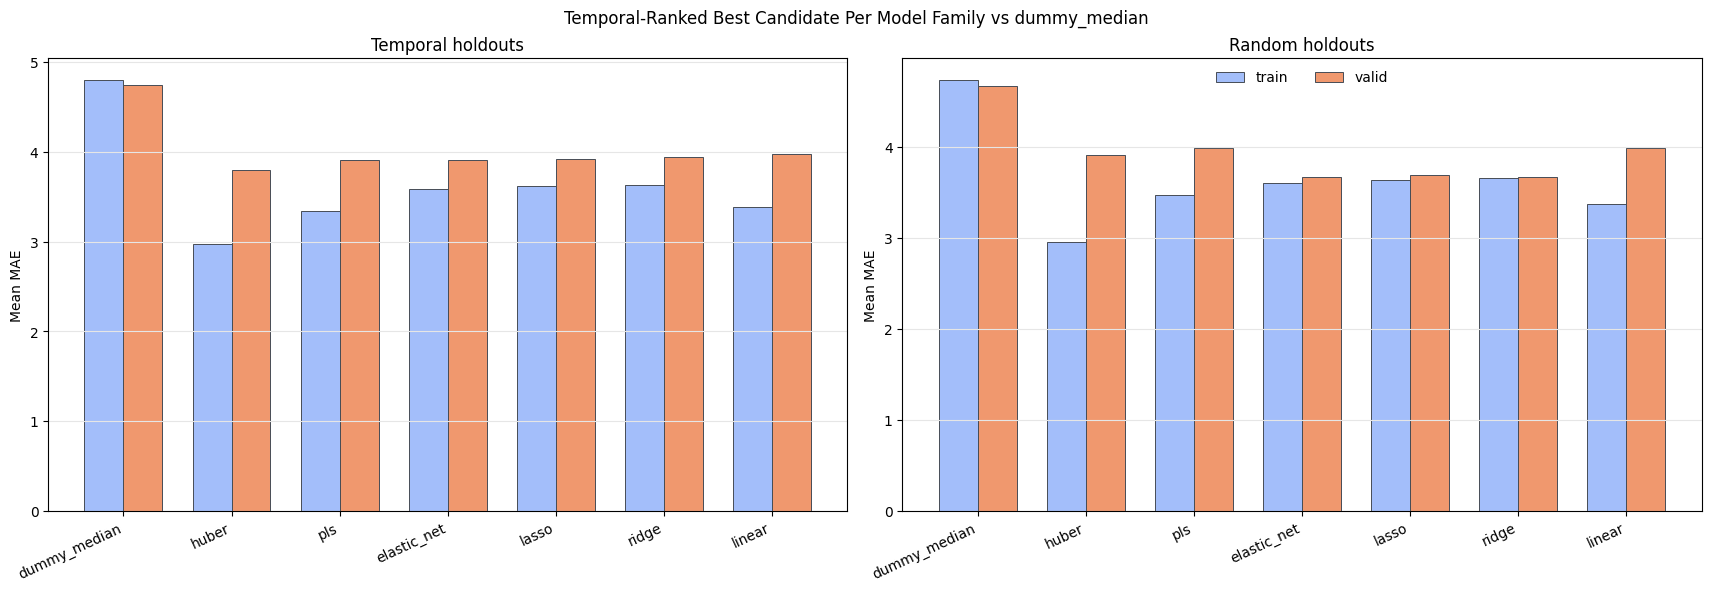

model_family_distribution


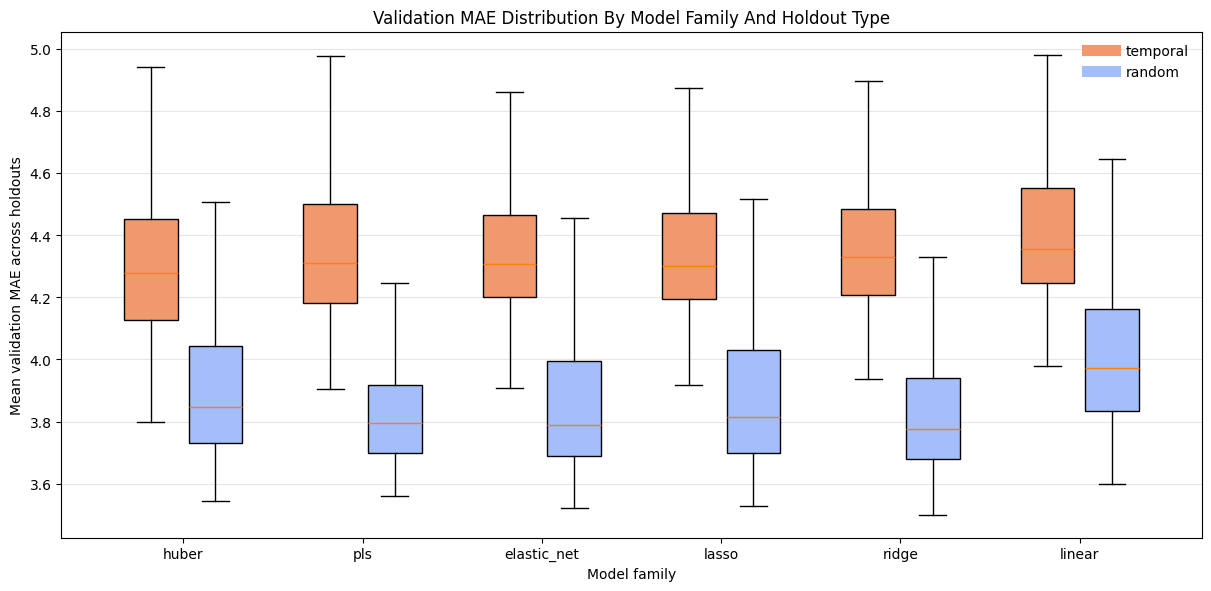

train_validation_gap


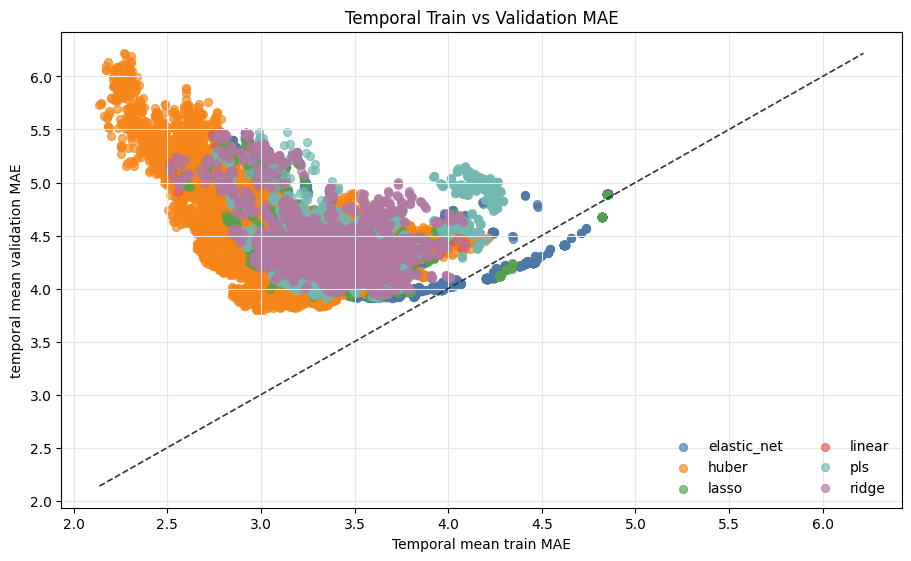

performance_stability


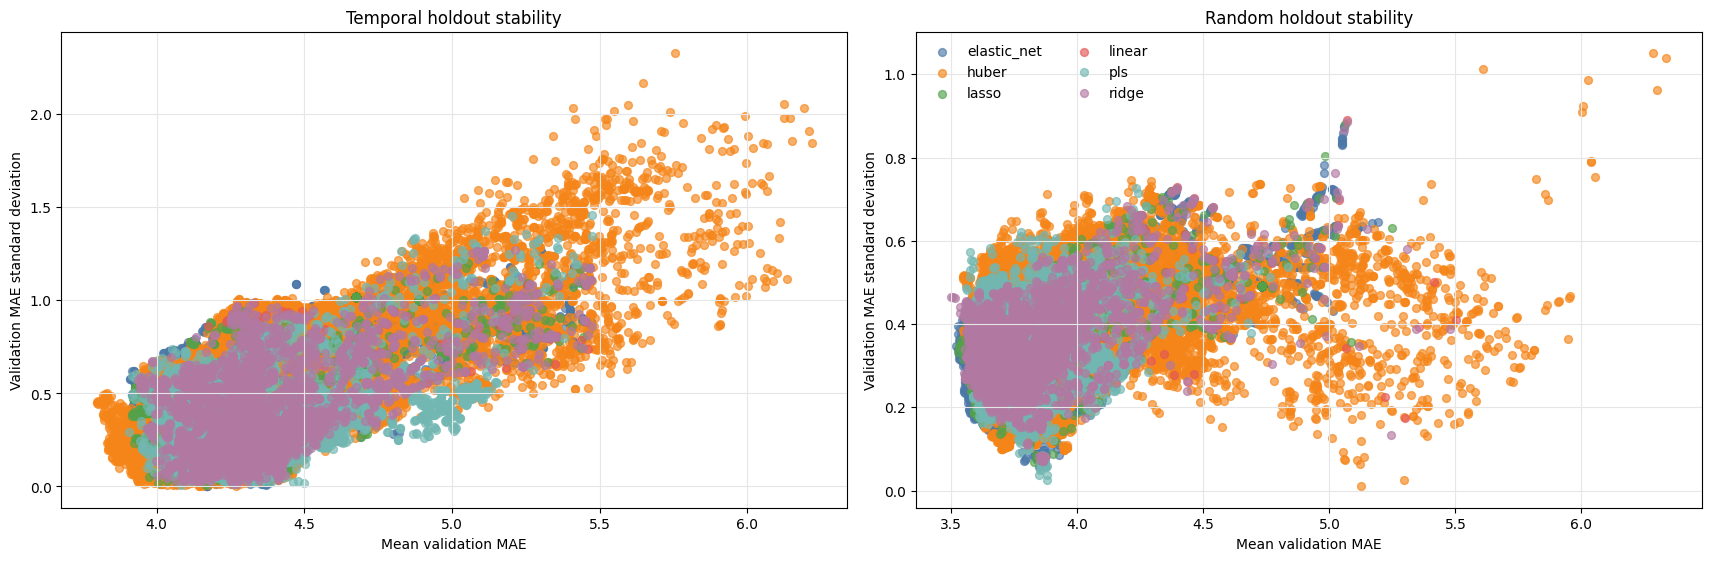

random_vs_temporal


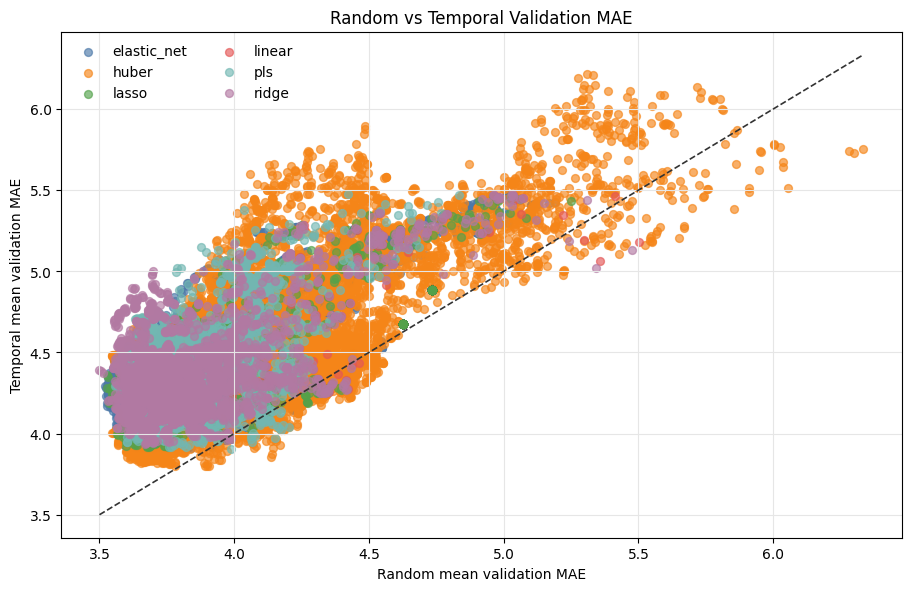

feature_count_tradeoff


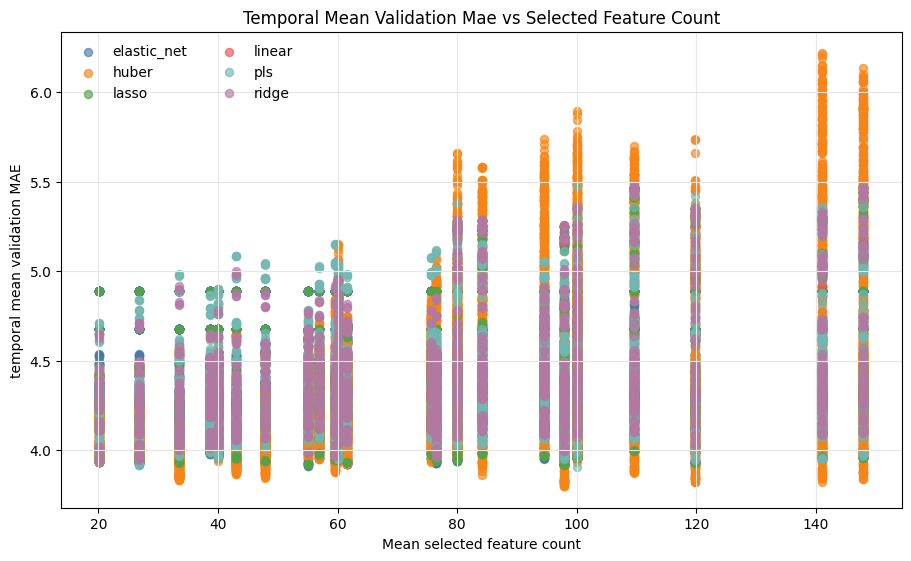

hyperparameter: ridge


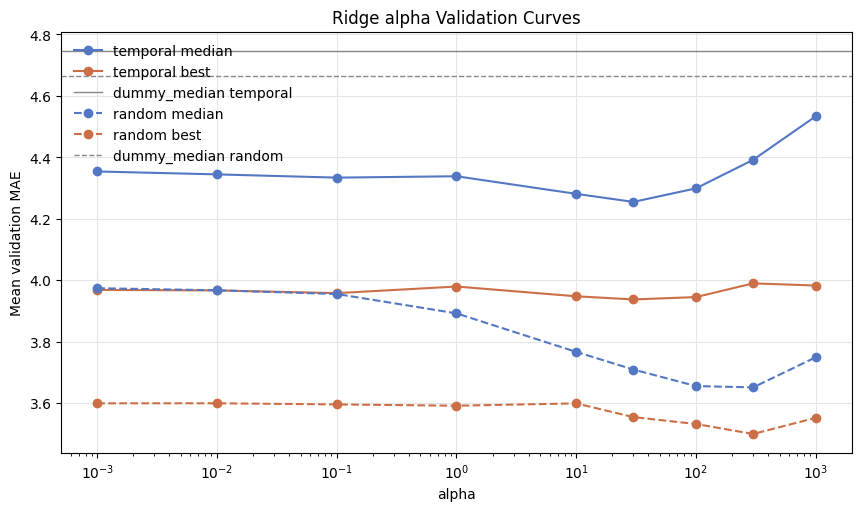

hyperparameter: lasso


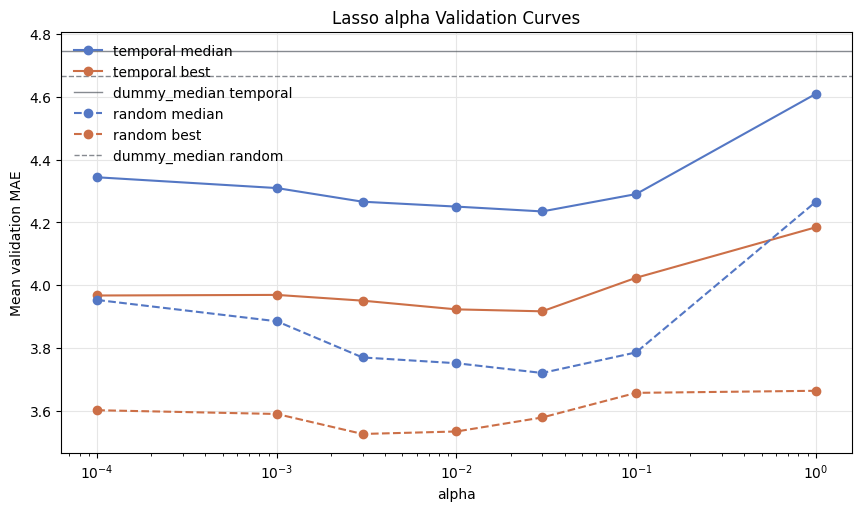

hyperparameter: pls


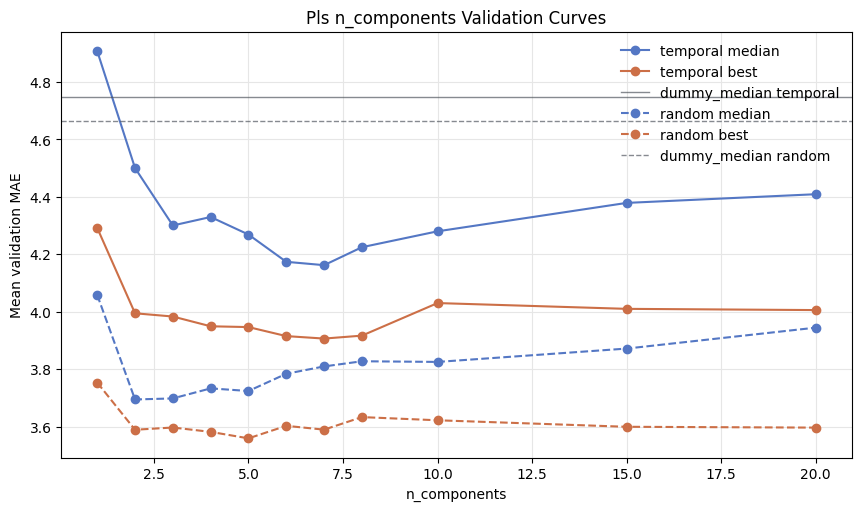

hyperparameter: elastic_net_alpha


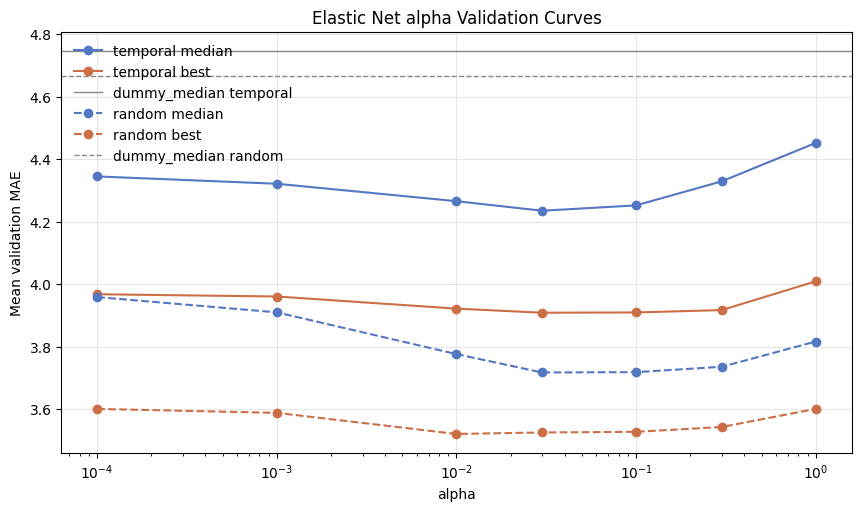

hyperparameter: elastic_net_l1_ratio


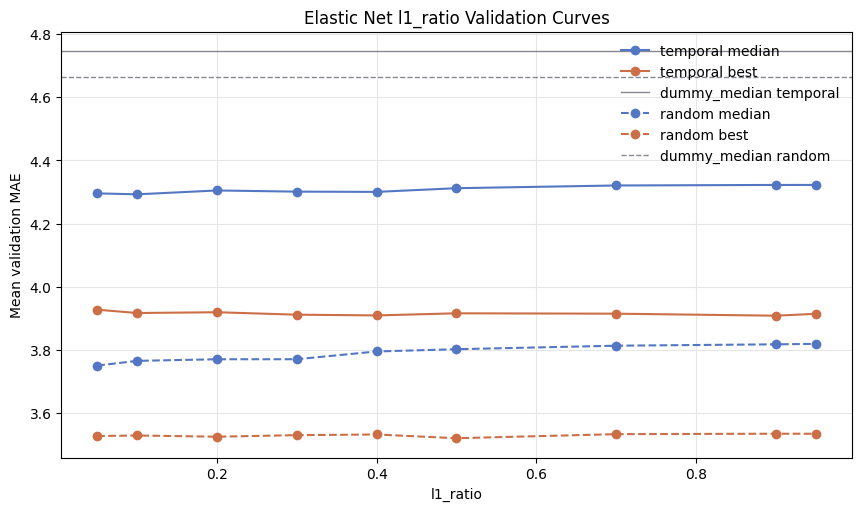

hyperparameter: huber_alpha


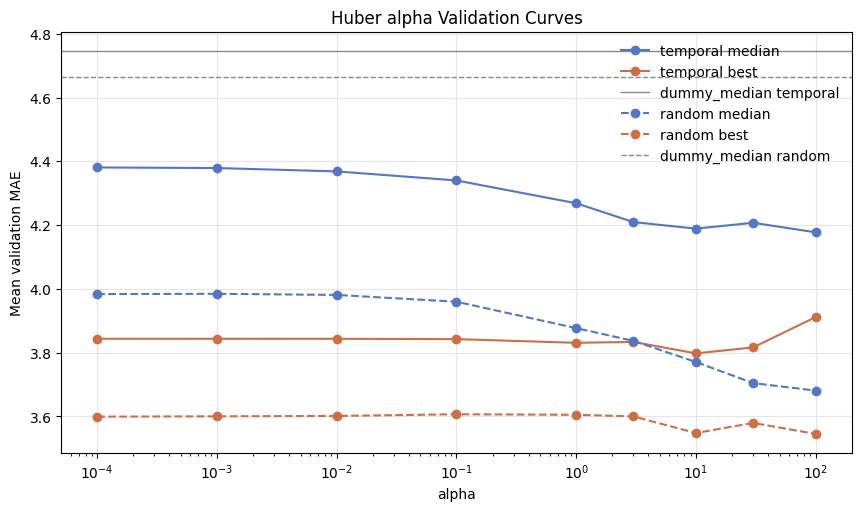

hyperparameter: huber_epsilon


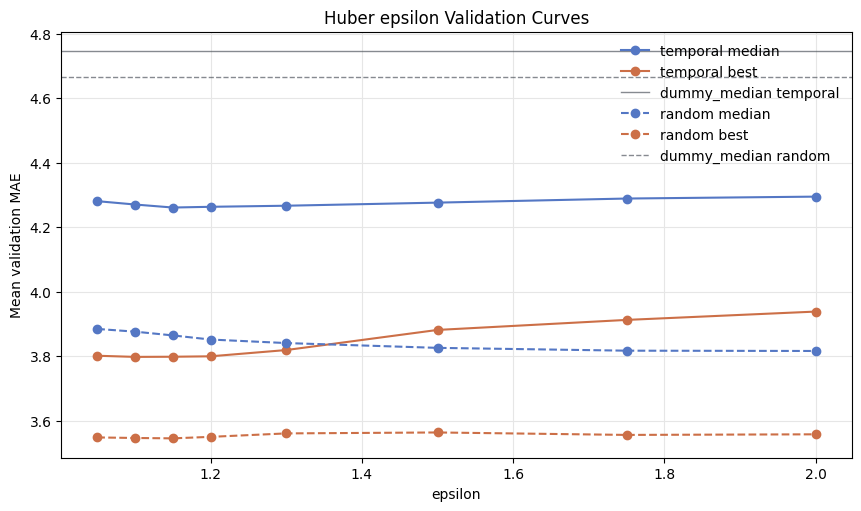

hyperparameter: elastic_net


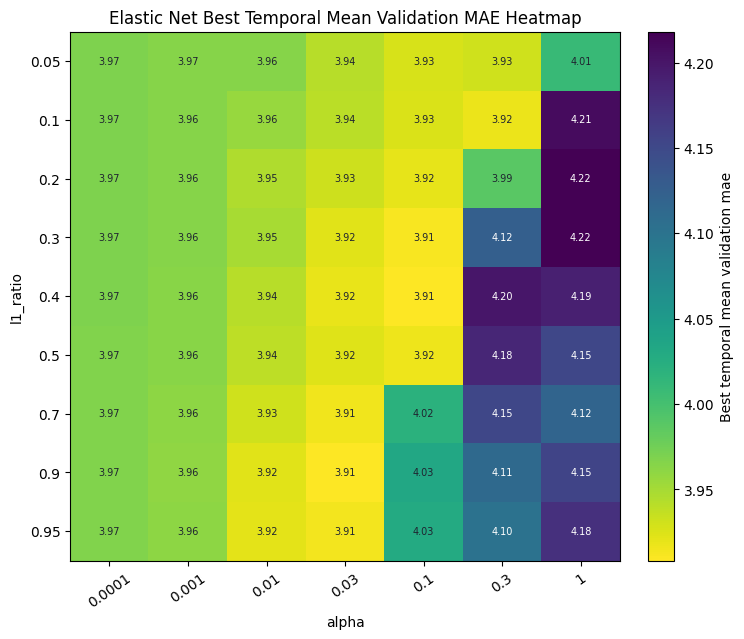

hyperparameter: huber


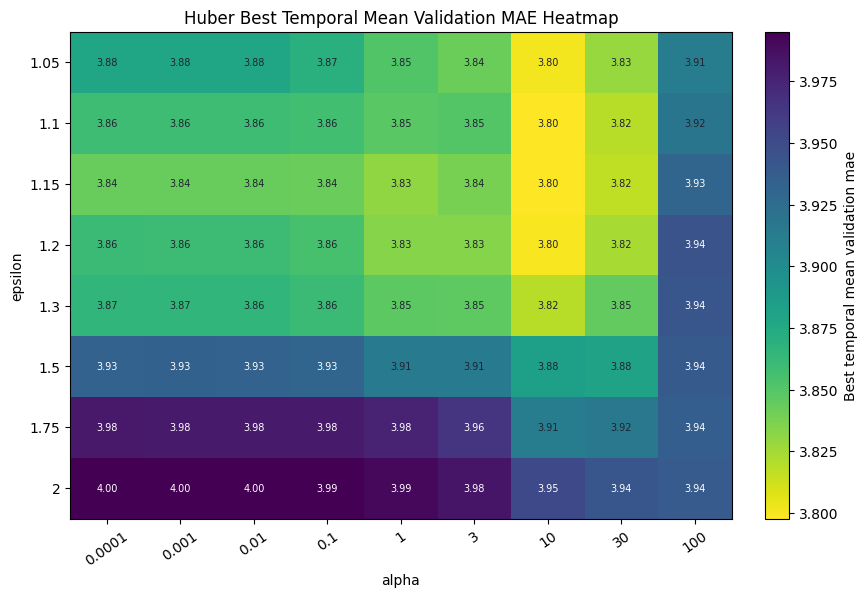

paired comparison: calibration_comparison


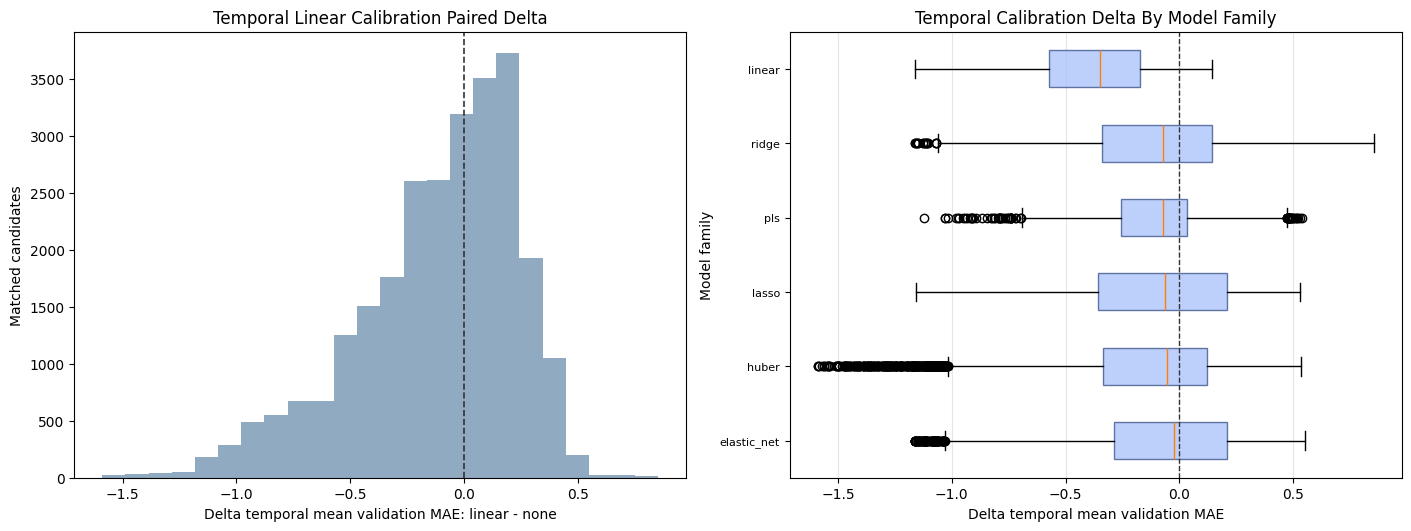

paired comparison: feature_selection_distribution


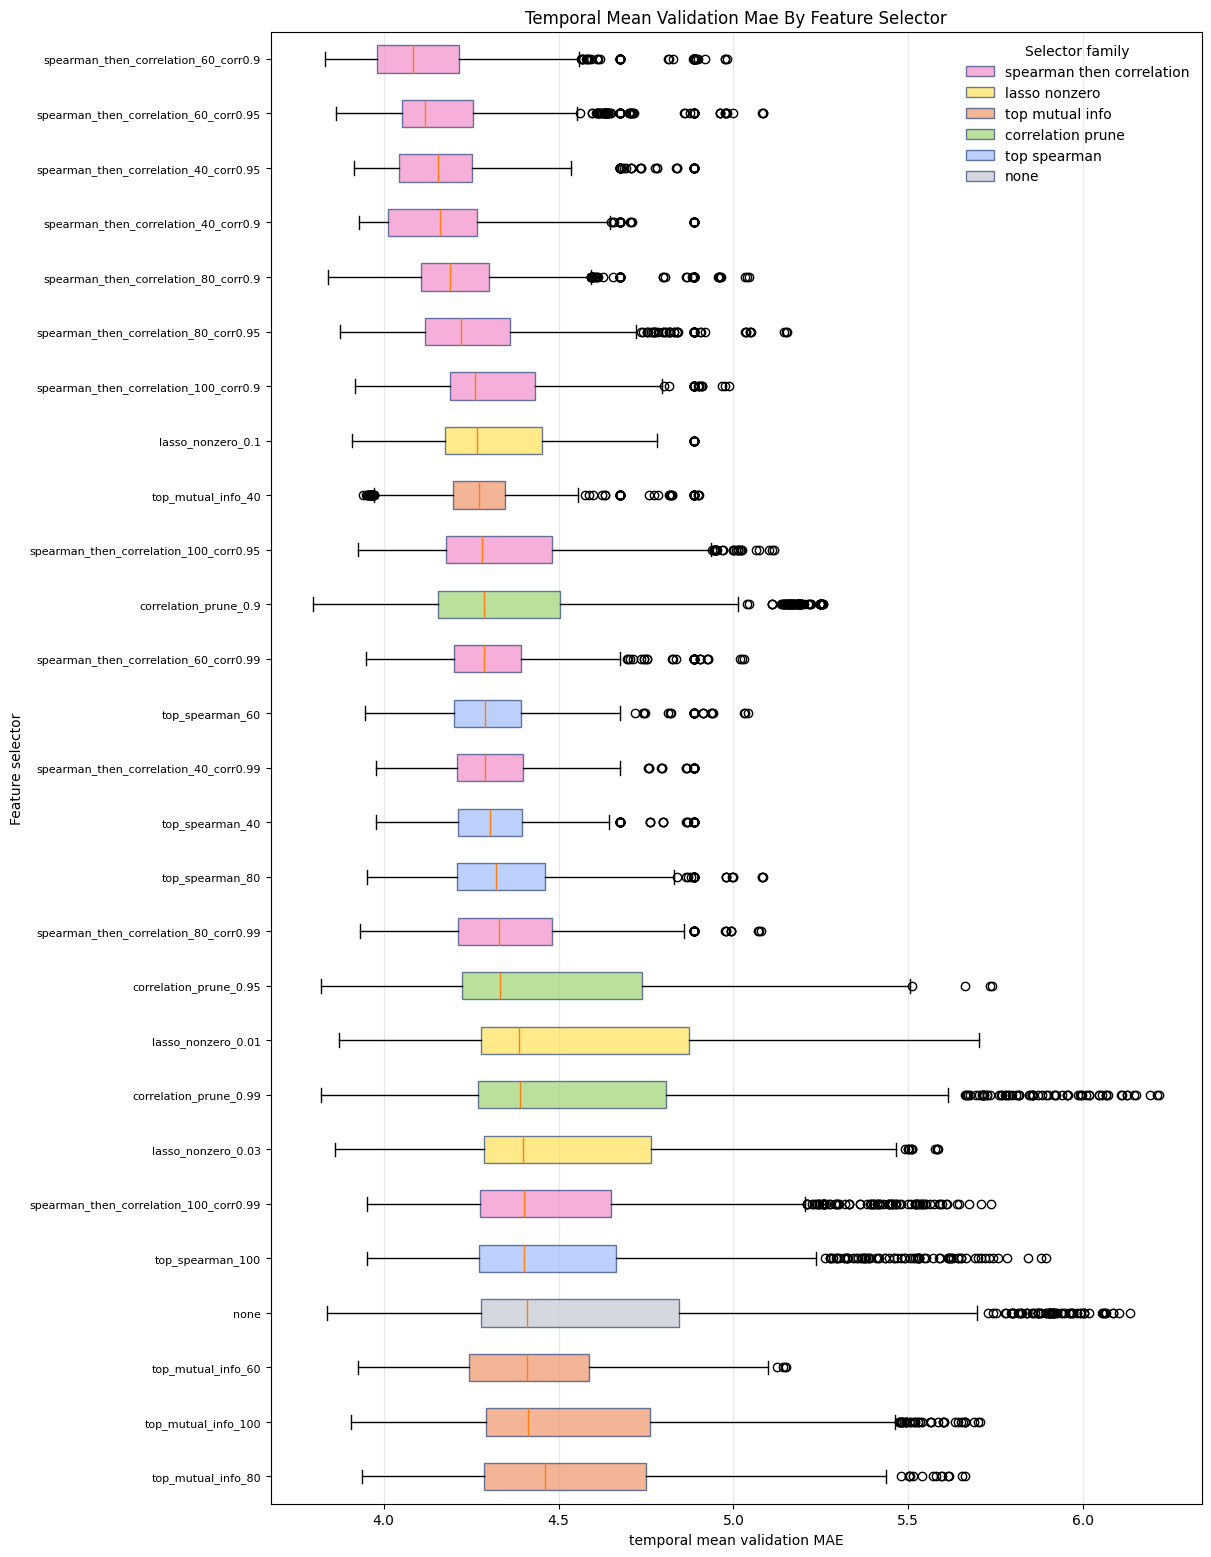

paired comparison: feature_selection_paired_delta


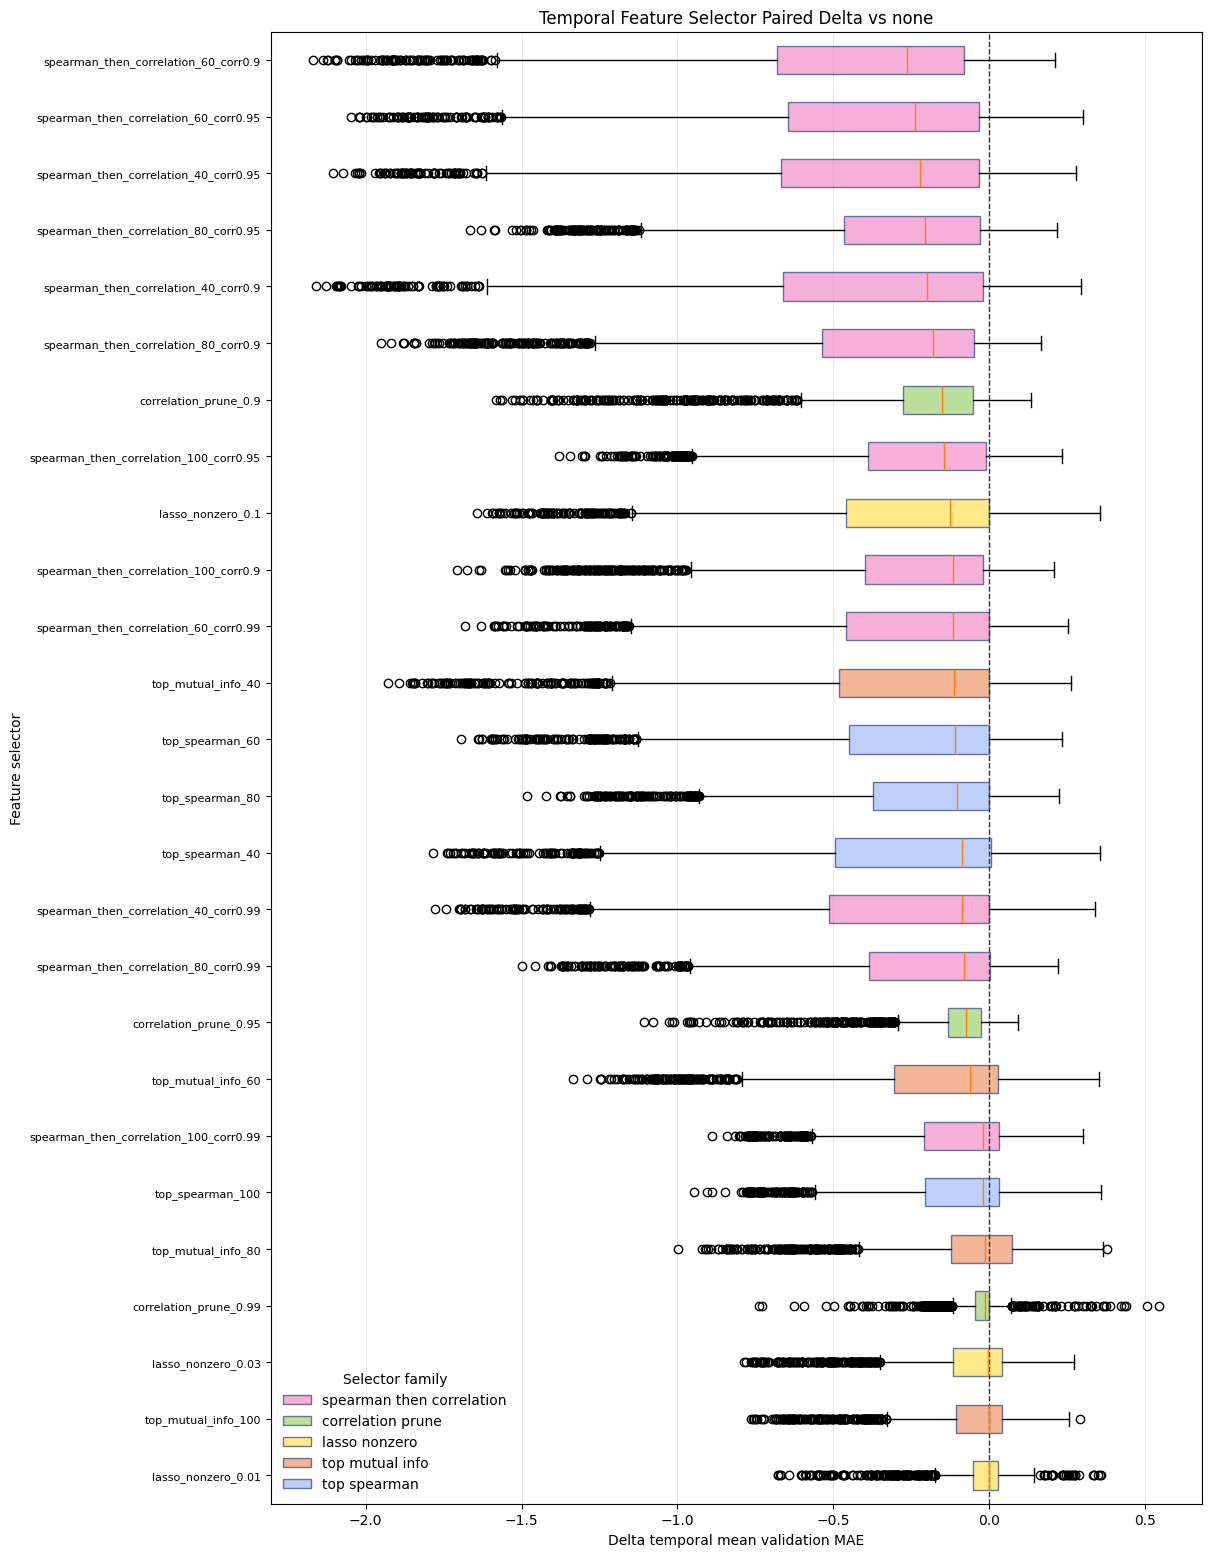

paired comparison: robust_clipping_comparison


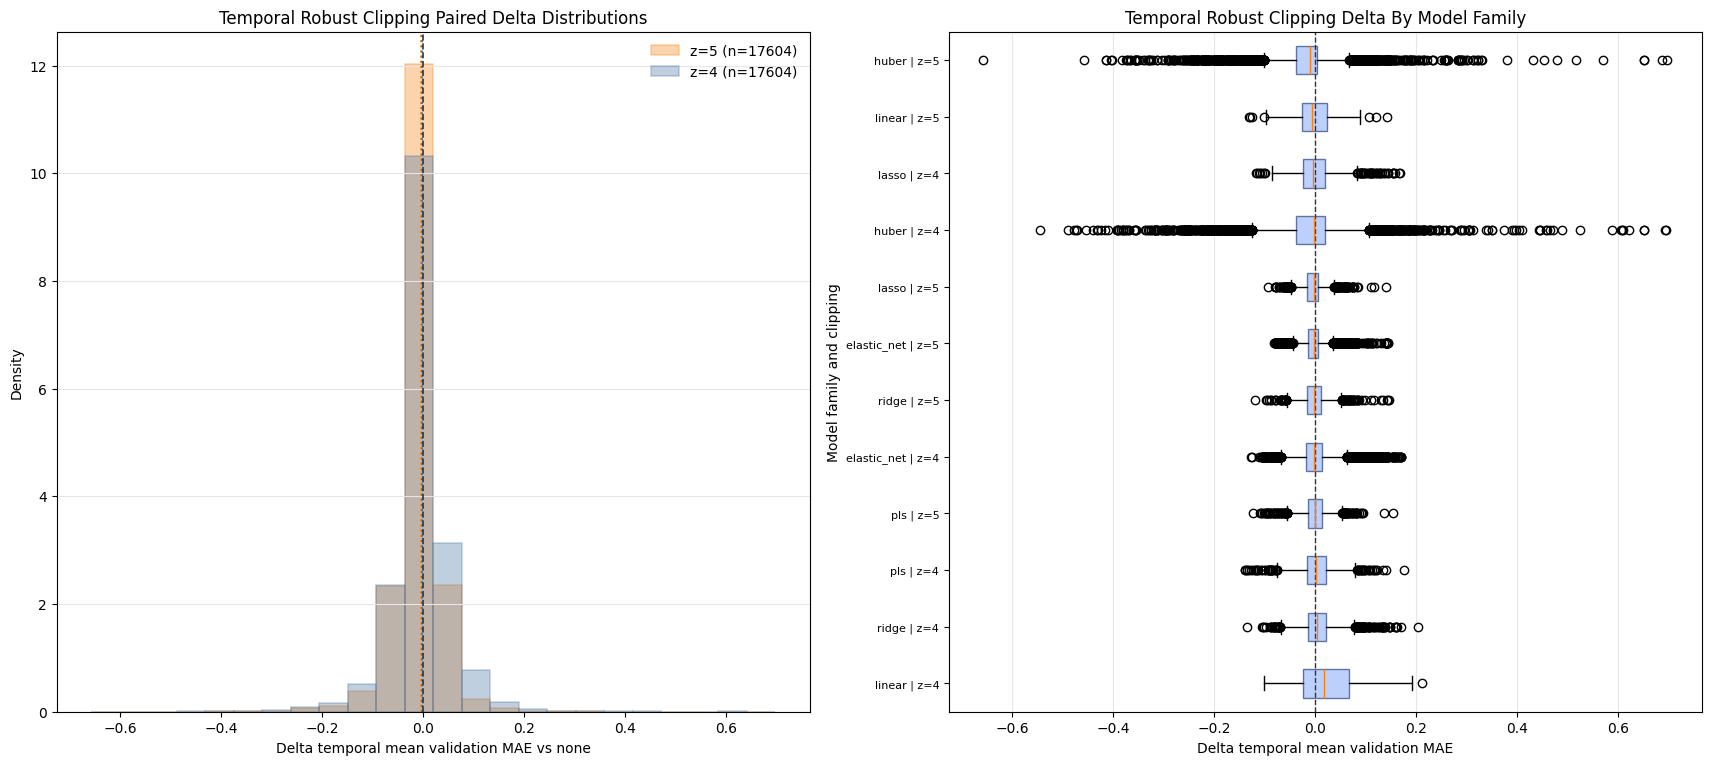

paired comparison: target_transform_comparison


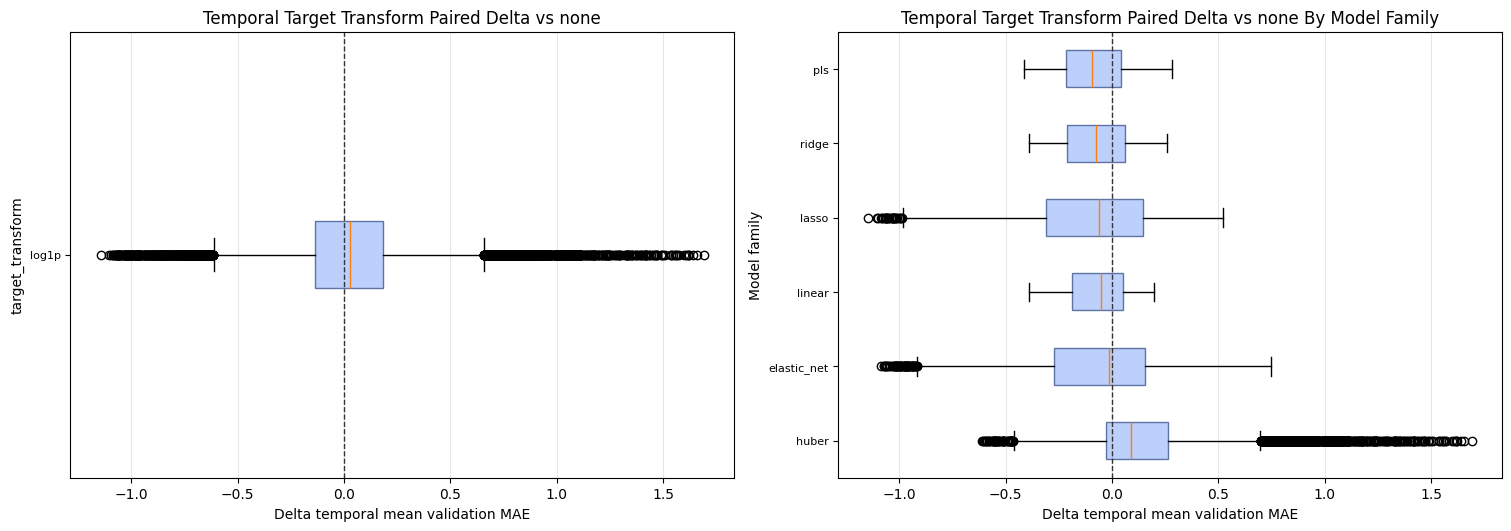

In [45]:
validation_figures = plot_stage4_linear_validation_diagnostics(
    tuning_result.tuning_summary,
    tuning_result.dummy_tuning_summary,
    top_n=25,
    top_per_model_family=INITIAL_DIAGNOSTIC_TOP_PER_MODEL_FAMILY,
    baseline_strategy=BASELINE_STRATEGY,
)
for figure_name, figure in validation_figures.items():
    print(figure_name)
    display(figure)
    plt.close(figure)

hyperparameter_figures = plot_stage4_linear_hyperparameter_diagnostics(
    tuning_result.tuning_summary,
    tuning_result.dummy_tuning_summary,
    baseline_strategy=BASELINE_STRATEGY,
)
for figure_name, figure in hyperparameter_figures.items():
    print(f"hyperparameter: {figure_name}")
    display(figure)
    plt.close(figure)

factor_comparison_figures = plot_stage4_linear_factor_comparisons(
    tuning_result.tuning_summary,
)
for figure_name, figure in factor_comparison_figures.items():
    print(f"paired comparison: {figure_name}")
    display(figure)
    plt.close(figure)


## Stage 2: Expanded Shortlist Rerank

This validation-only stage reevaluates the representative shortlist on more random and temporal holdouts. When enabled, its ranking becomes the definitive source for the final global leader, model-family representatives, and all candidates allowed to reach the future test.


In [46]:
if RUN_SHORTLIST_RERANK:
    if tuning_result.shortlist_summary.empty:
        raise RuntimeError("The initial mixed tuning run did not produce a shortlist.")

    shortlist_candidates = [
        stage4_linear_candidate_from_record(record)
        for record in tuning_result.shortlist_summary.to_dict("records")
    ]
    shortlist_rerank_config = replace(
        config,
        grid_source="control_panel",
        repeated_holdout_repeats=SHORTLIST_RERANK_RANDOM_HOLDOUTS,
        temporal_holdout_repeats=SHORTLIST_RERANK_TEMPORAL_HOLDOUTS,
        temporal_validation_rows=SHORTLIST_RERANK_TEMPORAL_VALIDATION_ROWS,
        shortlist_count=min(SHORTLIST_COUNT, len(shortlist_candidates)),
    )
    progress_state = {
        "started": time.perf_counter(),
        "last_render": 0.0,
        "completed": 0,
        "total": len(shortlist_candidates) * (
            SHORTLIST_RERANK_RANDOM_HOLDOUTS + SHORTLIST_RERANK_TEMPORAL_HOLDOUTS
        ),
    }
    progress_handle = display(pd.DataFrame([{"status": "starting shortlist rerank"}]), display_id=True)
    shortlist_rerank_result = tune_stage4_linear_modeling(
        frame,
        feature_catalog,
        config=shortlist_rerank_config,
        candidates=shortlist_candidates,
        progress_callback=update_tuning_progress,
    )
    update_tuning_progress(progress_state["total"], progress_state["total"], status="complete")
    selection_tuning_result = shortlist_rerank_result
    print("Expanded shortlist rerank complete; this is now the definitive validation ranking.")
    display(
        shortlist_rerank_result.tuning_summary[
            [
                "selection_rank",
                "candidate_id",
                "candidate_short_label",
                "model_kind",
                "combined_rank_score",
                "temporal_mean_relative_mae",
                "temporal_worst_relative_mae",
                "random_mean_relative_mae",
                "random_relative_mae_std",
                "baseline_gate_pass",
            ]
        ].head(50)
    )
else:
    selection_tuning_result = tuning_result
    print("Expanded shortlist rerank is disabled; final selection will use the initial mixed ranking.")


,status
0,starting shortlist rerank


Expanded shortlist rerank complete; this is now the definitive validation ranking.


,selection_rank,candidate_id,candidate_short_label,model_kind,combined_rank_score,temporal_mean_relative_mae,temporal_worst_relative_mae,random_mean_relative_mae,random_relative_mae_std,baseline_gate_pass
0,1,19240,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,0.080000,0.822975,0.952264,0.765022,0.063237,True
1,2,19252,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,0.081000,0.821569,0.969132,0.764362,0.064760,True
2,3,21208,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,0.085333,0.822800,0.958279,0.761692,0.067252,True
3,4,19256,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,0.085333,0.821756,0.963765,0.765015,0.065549,True
4,5,19268,Huber alpha=30 eps=1.15 | correlation_prune_0....,huber,0.090333,0.820784,0.973281,0.764626,0.065476,True
5,6,19264,Huber alpha=30 eps=1.15 | correlation_prune_0....,huber,0.097333,0.820184,0.977752,0.764497,0.065013,True
6,7,19280,Huber alpha=30 eps=1.2 | correlation_prune_0.9...,huber,0.098000,0.819857,0.978415,0.764336,0.065206,True
7,8,21196,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,0.099000,0.825932,0.953621,0.762548,0.065790,True
8,9,19276,Huber alpha=30 eps=1.2 | correlation_prune_0.9...,huber,0.104667,0.819646,0.982385,0.764085,0.065100,True
9,10,19244,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,0.118667,0.826382,0.962486,0.766215,0.064776,True


## Stage 2 Definitive Validation Results And Future-Test Selection

The tables and plot below use `selection_tuning_result`: the expanded rerank when enabled, otherwise the initial mixed run. This is the final validation-only decision point.

There is no single canonical train/validation prediction plot before refit because mixed validation contains many random and temporal holdouts; selecting one fold would be arbitrary. The aggregate validation tables and family comparison summarize all rerank holdouts instead.

The future-test list contains the requested global validation leaders plus the best validation-ranked representatives of every model family. Duplicate candidates are included only once. The list is frozen before the future test is opened.


Definitive stored holdout evaluations reaggregated; candidate models were not refit.
Definitive validation ranking


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count,random_baseline_wins,temporal_baseline_wins,baseline_gate_pass,combined_rank_score
0,1,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,alpha=30,epsilon=1.05,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,z=4,...,3.586633,0.505146,4.994950,0.336215,0.587408,98.222222,10,8,True,0.080000
1,2,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,alpha=30,epsilon=1.1,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,z=4,...,3.583055,0.507793,4.998376,0.336291,0.587283,98.222222,10,8,True,0.081000
2,3,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,alpha=30,epsilon=1.1,correlation_prune,correlation_prune_0.95,corr=0.95,min_features=8,z=4,...,3.572513,0.459896,4.989559,0.335562,0.593308,120.277778,10,8,True,0.085333
3,4,Huber alpha=30 eps=1.1 | correlation_prune_0.9...,huber,alpha=30,epsilon=1.1,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,z=5,...,3.583735,0.500523,4.993704,0.336946,0.587133,98.222222,10,8,True,0.085333
4,5,Huber alpha=30 eps=1.15 | correlation_prune_0....,huber,alpha=30,epsilon=1.15,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,z=5,...,3.580880,0.504446,4.992466,0.337286,0.589090,98.222222,10,8,True,0.090333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Linear | spearman_then_correlation_80_corr0.95...,linear,,,spearman_then_correlation,spearman_then_correlation_80_corr0.95,top_k=80,corr=0.95,z=4,...,3.790824,0.490267,5.179355,0.280647,0.563400,60.555556,10,8,True,0.597000
96,97,Ridge alpha=1000 | lasso_nonzero_0.1 | clip=no...,ridge,alpha=1000,,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,none,...,3.819162,0.540871,5.274801,0.266635,0.596525,55.000000,10,8,True,0.613667
97,98,PLS k=6 | top_mutual_info_60 | clip=z=4 | cal=...,pls,n_components=6,,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=4,...,3.672304,0.524349,5.008638,0.324613,0.573973,60.000000,10,8,True,0.619333
98,99,Huber alpha=0.1 eps=1.1 | lasso_nonzero_0.1 | ...,huber,alpha=0.1,epsilon=1.1,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,z=5,...,3.721010,0.463307,5.165160,0.289944,0.562643,55.000000,10,7,True,0.621667


Definitive best candidate per model family


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count,random_baseline_wins,temporal_baseline_wins,baseline_gate_pass,combined_rank_score
0,1,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,alpha=30,epsilon=1.05,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,z=4,...,3.586633,0.505146,4.994950,0.336215,0.587408,98.222222,10,8,True,0.080000
1,30,ElasticNet alpha=0.1 l1=0.1 | top_mutual_info_...,elastic_net,alpha=0.1,l1_ratio=0.1,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=4,...,3.651351,0.495901,4.976161,0.334770,0.583896,60.000000,10,8,True,0.291667
2,49,Lasso alpha=0.01 | correlation_prune_0.9 | cli...,lasso,alpha=0.01,,correlation_prune,correlation_prune_0.9,corr=0.9,min_features=8,none,...,3.590045,0.478004,4.930883,0.345784,0.606499,98.222222,10,7,True,0.379000
3,96,Linear | spearman_then_correlation_80_corr0.95...,linear,,,spearman_then_correlation,spearman_then_correlation_80_corr0.95,top_k=80,corr=0.95,z=4,...,3.790824,0.490267,5.179355,0.280647,0.563400,60.555556,10,8,True,0.597000
4,97,Ridge alpha=1000 | lasso_nonzero_0.1 | clip=no...,ridge,alpha=1000,,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,none,...,3.819162,0.540871,5.274801,0.266635,0.596525,55.000000,10,8,True,0.613667
5,98,PLS k=6 | top_mutual_info_60 | clip=z=4 | cal=...,pls,n_components=6,,top_mutual_info,top_mutual_info_60,top_k=60,min_features=8,z=4,...,3.672304,0.524349,5.008638,0.324613,0.573973,60.000000,10,8,True,0.619333


Dummy baselines ranked on validation only; the configured comparison baseline is marked below


,model_kind,preselected_for_future_test_comparison,mean_valid_mae,std_valid_mae,random_mean_valid_mae,temporal_mean_valid_mae
0,dummy_median,True,4.575798,0.744155,4.564070,4.590458
1,dummy_mean,False,4.602380,0.771370,4.572030,4.640317
2,dummy_last,False,5.742420,3.537947,4.632056,7.130375


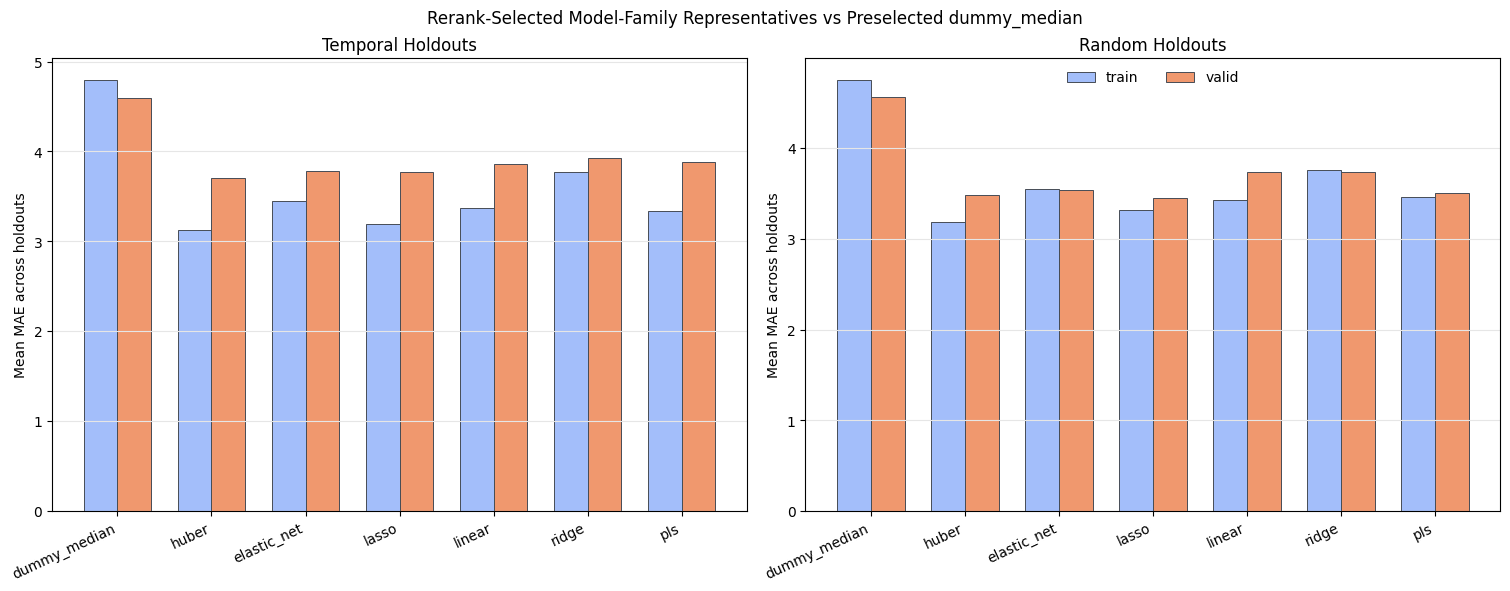

Validation-selected candidates allowed to reach the future test


,future_test_selection_order,selection_rank,candidate_id,candidate_short_label,model_kind,combined_rank_score,temporal_mean_relative_mae,temporal_worst_relative_mae,random_mean_relative_mae,future_test_selection_roles
0,1,1,19240,Huber alpha=30 eps=1.05 | correlation_prune_0....,huber,0.080000,0.822975,0.952264,0.765022,global_validation_leader|model_family_validati...
1,2,30,12389,ElasticNet alpha=0.1 l1=0.1 | top_mutual_info_...,elastic_net,0.291667,0.837563,0.954118,0.777494,model_family_validation_leader
2,3,49,17761,Lasso alpha=0.01 | correlation_prune_0.9 | cli...,lasso,0.379000,0.837713,1.003206,0.756634,model_family_validation_leader
3,4,96,37170,Linear | spearman_then_correlation_80_corr0.95...,linear,0.597000,0.856412,0.956951,0.817460,model_family_validation_leader
4,5,97,50965,Ridge alpha=1000 | lasso_nonzero_0.1 | clip=no...,ridge,0.613667,0.866640,0.945861,0.818630,model_family_validation_leader
5,6,98,13627,PLS k=6 | top_mutual_info_60 | clip=z=4 | cal=...,pls,0.619333,0.858303,0.988101,0.769140,model_family_validation_leader


In [47]:
selection_tuning_result = refresh_stage4_linear_tuning_result_summaries(selection_tuning_result)
print("Definitive stored holdout evaluations reaggregated; candidate models were not refit.")

definitive_overall = selection_tuning_result.validation_slices["overall_validation"]
definitive_by_model = selection_tuning_result.validation_slices["best_by_model_kind"]
definitive_dummy = selection_tuning_result.validation_slices["dummy_validation"]

print("Definitive validation ranking")
display(definitive_overall[validation_cols].head(100))
print("Definitive best candidate per model family")
display(definitive_by_model[validation_cols])
print("Dummy baselines ranked on validation only; the configured comparison baseline is marked below")
definitive_dummy_display = definitive_dummy.copy()
definitive_dummy_display["preselected_for_future_test_comparison"] = definitive_dummy_display["model_kind"].eq(BASELINE_STRATEGY)
display(
    definitive_dummy_display[
        [
            "model_kind",
            "preselected_for_future_test_comparison",
            "mean_valid_mae",
            "std_valid_mae",
            "random_mean_valid_mae",
            "temporal_mean_valid_mae",
        ]
    ]
)

mixed_family_fig = plot_stage4_linear_mixed_validation_family_comparison(
    selection_tuning_result.tuning_summary,
    selection_tuning_result.dummy_tuning_summary,
    baseline_strategy=BASELINE_STRATEGY,
)
display(mixed_family_fig)
plt.close(mixed_family_fig)

future_test_selection = select_stage4_linear_future_test_candidates(
    selection_tuning_result.tuning_summary,
    global_top_n=FUTURE_TEST_GLOBAL_TOP_N,
    model_family_top_n=FUTURE_TEST_MODEL_FAMILY_TOP_N,
)
future_test_candidate_ids = future_test_selection["candidate_id"].astype(int).tolist()
print("Validation-selected candidates allowed to reach the future test")
display(
    future_test_selection[
        [
            "future_test_selection_order",
            "selection_rank",
            "candidate_id",
            "candidate_short_label",
            "model_kind",
            "combined_rank_score",
            "temporal_mean_relative_mae",
            "temporal_worst_relative_mae",
            "random_mean_relative_mae",
            "future_test_selection_roles",
        ]
    ]
)


## Pre-Refit Contiguous Dev Prediction Diagnostic

The definitive validation-selected rank-1 candidate is fit on the earliest 70% of `dev` and evaluated on three contiguous segments inside `dev`: `dev_train` 70%, `dev_valid` 15%, and `dev_test` 15%. This is a diagnostic view of temporal degradation, not an additional untouched evaluation: the candidate was already selected using mixed holdouts over dev.

The reserved future test is not read here. Residual histograms are normalized so the unequal segment sizes can be compared directly.


,split,mae,rmse,r2,bias_pred_minus_target
0,dev_train,3.144828,4.879048,0.471532,-0.454534
1,dev_valid,4.106599,7.018843,0.343489,0.454314
2,dev_test,4.036347,4.852561,0.181131,1.715586


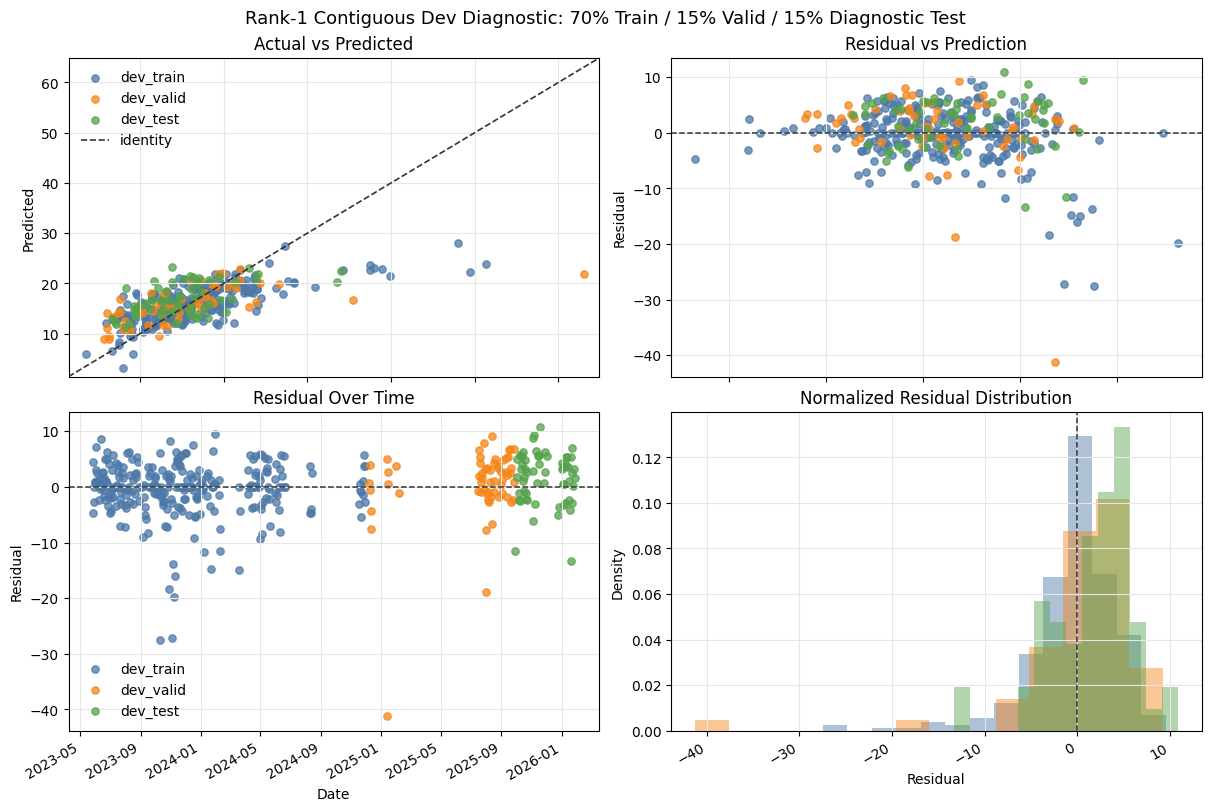

In [48]:
rank1_validation_record = selection_tuning_result.tuning_summary.sort_values("selection_rank").iloc[0].to_dict()
rank1_validation_candidate = stage4_linear_candidate_from_record(rank1_validation_record)
contiguous_dev_metrics, contiguous_dev_predictions = evaluate_stage4_linear_contiguous_dev_diagnostic(
    selection_tuning_result.splits,
    selection_tuning_result.feature_columns,
    rank1_validation_candidate,
    config=selection_tuning_result.config,
    train_fraction=0.70,
    valid_fraction=0.15,
)
display(contiguous_dev_metrics[["split", "mae", "rmse", "r2", "bias_pred_minus_target"]])
contiguous_dev_fig = plot_stage4_linear_prediction_diagnostics(
    contiguous_dev_predictions,
    target_col=TARGET_COL,
    validation_selection_rank=1,
    splits=("dev_train", "dev_valid", "dev_test"),
    normalize_histogram=True,
    title="Rank-1 Contiguous Dev Diagnostic: 70% Train / 15% Valid / 15% Diagnostic Test",
)
display(contiguous_dev_fig)
plt.close(contiguous_dev_fig)


## Final Refit On Dev And One-Time Future-Test Evaluation

Only the frozen validation-selected list is refit on all `dev` rows. The old train/validation labels no longer have out-of-sample meaning after this refit, so post-refit metrics and predictions are reported only for `dev` and the reserved future `test` block.


In [49]:
result = finalize_stage4_linear_modeling(
    selection_tuning_result,
    finalist_candidate_ids=future_test_candidate_ids,
)

print("Validation-selected candidates refit on all dev rows; reserved future test evaluated once.")
display(
    pd.DataFrame(
        [
            {
                "validation_selected_finalists": len(result.model_selection_summary),
                "final_refit_rows": int(result.model_selection_summary["final_refit_rows"].max()),
                "post_refit_splits": ", ".join(sorted(result.final_metrics["split"].unique())),
                "future_test_evaluated": True,
            }
        ]
    )
)


Validation-selected candidates refit on all dev rows; reserved future test evaluated once.


,validation_selected_finalists,final_refit_rows,post_refit_splits,future_test_evaluated
0,6,401,"dev, test",True


## Future Test Readout

The candidate order and comparison baseline were fixed by validation before this section. Test metrics are evaluation-only and must not be used to replace either the selected model or `BASELINE_STRATEGY`.


In [50]:
future_test = result.leaderboard_slices["final_future_test"].sort_values("validation_selection_rank").reset_index(drop=True)
future_dummy_metrics = result.dummy_metrics.query("split == 'test'").copy()
future_dummy_readout = (
    selection_tuning_result.dummy_tuning_summary[
        ["model_kind", "selection_metric_value", "mean_valid_mae", "std_valid_mae"]
    ]
    .merge(
        future_dummy_metrics[["model_kind", "baseline_value", "mae", "rmse", "r2", "bias_pred_minus_target"]],
        on="model_kind",
        how="left",
    )
    .sort_values("selection_metric_value")
    .reset_index(drop=True)
)
future_dummy_readout["preselected_for_comparison"] = future_dummy_readout["model_kind"].eq(BASELINE_STRATEGY)

test_cols = [
    "validation_selection_rank",
    "model_kind",
    "feature_selection_mode",
    "robust_clip",
    "calibration",
    "mae",
    "rmse",
    "r2",
    "pearson",
    "spearman",
    "bias_pred_minus_target",
    "selected_feature_count_final_refit",
]
display(future_test[test_cols])
display(
    future_dummy_readout[
        [
            "model_kind",
            "preselected_for_comparison",
            "mean_valid_mae",
            "baseline_value",
            "mae",
            "rmse",
            "r2",
            "bias_pred_minus_target",
        ]
    ]
)

rank1 = future_test.iloc[0]
selected_baseline = future_dummy_readout.loc[future_dummy_readout["model_kind"].eq(BASELINE_STRATEGY)].iloc[0]
comparison = pd.DataFrame(
    [
        {
            "validation_selected_model": rank1["model_kind"],
            "validation_rank": int(rank1["validation_selection_rank"]),
            "model_test_mae": rank1["mae"],
            "preselected_baseline": selected_baseline["model_kind"],
            "baseline_test_mae": selected_baseline["mae"],
            "mae_improvement_vs_preselected_baseline": selected_baseline["mae"] - rank1["mae"],
            "mae_pct_improvement_vs_preselected_baseline": 100.0 * (selected_baseline["mae"] - rank1["mae"]) / selected_baseline["mae"],
        }
    ]
)
display(comparison)


,validation_selection_rank,model_kind,feature_selection_mode,robust_clip,calibration,mae,rmse,r2,pearson,spearman,bias_pred_minus_target,selected_feature_count_final_refit
0,1,huber,correlation_prune,z=4,none,5.326997,8.825444,0.264439,0.602982,0.600407,-2.777924,100
1,30,elastic_net,top_mutual_info,z=4,none,5.075020,8.184416,0.367412,0.652407,0.634043,-1.997092,60
2,49,lasso,correlation_prune,none,none,5.259505,8.603618,0.300950,0.603819,0.600609,-2.497856,100
3,96,linear,spearman_then_correlation,z=4,linear,5.092822,8.200517,0.364920,0.635144,0.626967,-1.942833,61
4,97,ridge,lasso_nonzero,none,none,5.420758,8.989171,0.236894,0.617147,0.590129,-2.754168,53
5,98,pls,top_mutual_info,z=4,linear,5.046887,7.876604,0.414100,0.682823,0.642460,-1.642009,60


,model_kind,preselected_for_comparison,mean_valid_mae,baseline_value,mae,rmse,r2,bias_pred_minus_target
0,dummy_median,True,4.575798,15.580000,6.326338,10.772640,-0.095948,-3.187465
1,dummy_mean,False,4.602380,16.161297,6.198213,10.615176,-0.064143,-2.606168
2,dummy_last,False,5.742420,14.380000,6.689155,11.186585,-0.181791,-4.387465


,validation_selected_model,validation_rank,model_test_mae,preselected_baseline,baseline_test_mae,mae_improvement_vs_preselected_baseline,mae_pct_improvement_vs_preselected_baseline
0,huber,1,5.326997,dummy_median,6.326338,0.999341,15.796523


## Post-Refit Dev/Test Model-Family Diagnostic

Every displayed model was selected by the definitive validation ranking and then refit on all `dev` rows. `dev` is therefore an in-sample refit diagnostic; `test` is the one-time future readout. There is deliberately no post-refit train/validation comparison.


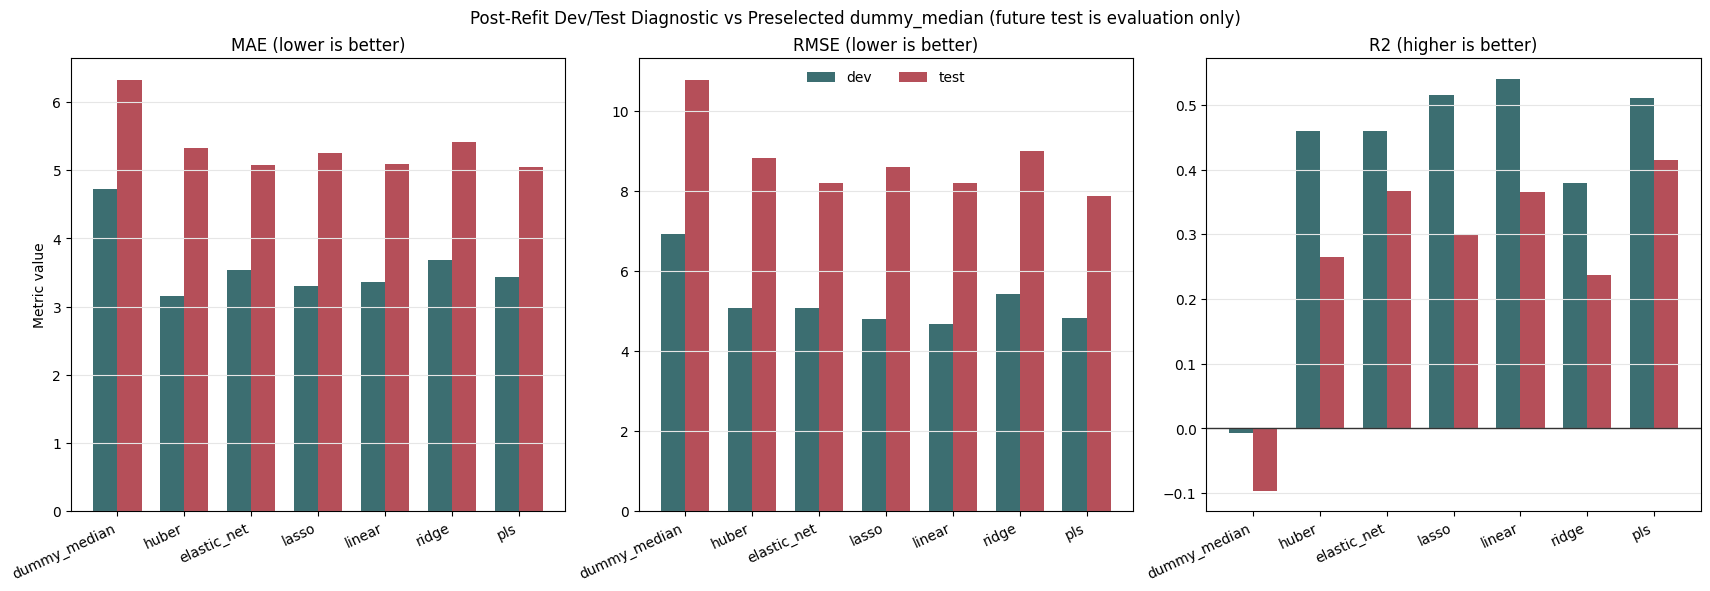

In [51]:
finalist_metric_fig = plot_stage4_linear_finalist_metric_comparison(
    result.final_metrics,
    result.dummy_metrics,
    baseline_strategy=BASELINE_STRATEGY,
)
display(finalist_metric_fig)
plt.close(finalist_metric_fig)


## Post-Refit Rank-1 Prediction Diagnostics

The rank-1 validation-selected model is shown on `dev` and future `test` only. The `dev` points are in-sample after the final refit; the future-test points are evaluation-only.


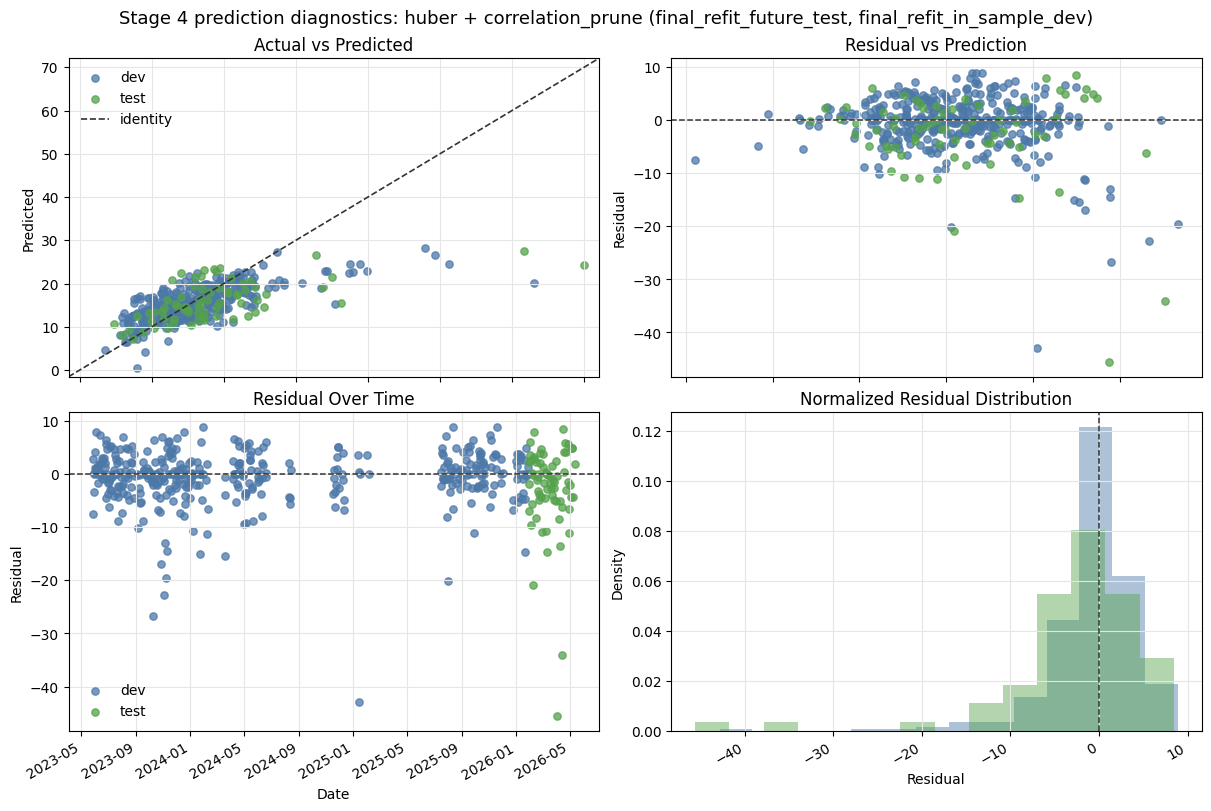

diagnostic_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_prediction_diagnostics.png


In [52]:
diagnostic_fig = plot_stage4_linear_prediction_diagnostics(
    result.final_predictions,
    target_col=TARGET_COL,
    validation_selection_rank=1,
    splits=("dev", "test"),
    save_path=diagnostic_figure_path,
)
display(diagnostic_fig)
plt.close(diagnostic_fig)
print("diagnostic_figure:", diagnostic_figure_path)


## Rank-1 Feature Importance Diagnostics

The two panels answer different questions and use independent top-N feature lists:

- **Dev-refit coefficients** come from the model fit on all dev rows. Numeric predictors are standardized before fitting, so the signed coefficients are on the preprocessed scale. They describe model direction and linear effect size, not out-of-sample importance.
- **Contiguous validation permutation importance** comes from a separate model fit on the original train block and evaluated on the contiguous validation block. Its unit is the increase in validation MAE after shuffling one feature.

Feature selection is refit separately for the dev-refit and validation-fit models, so their selected feature sets may differ. The reserved future test is not used for either panel.


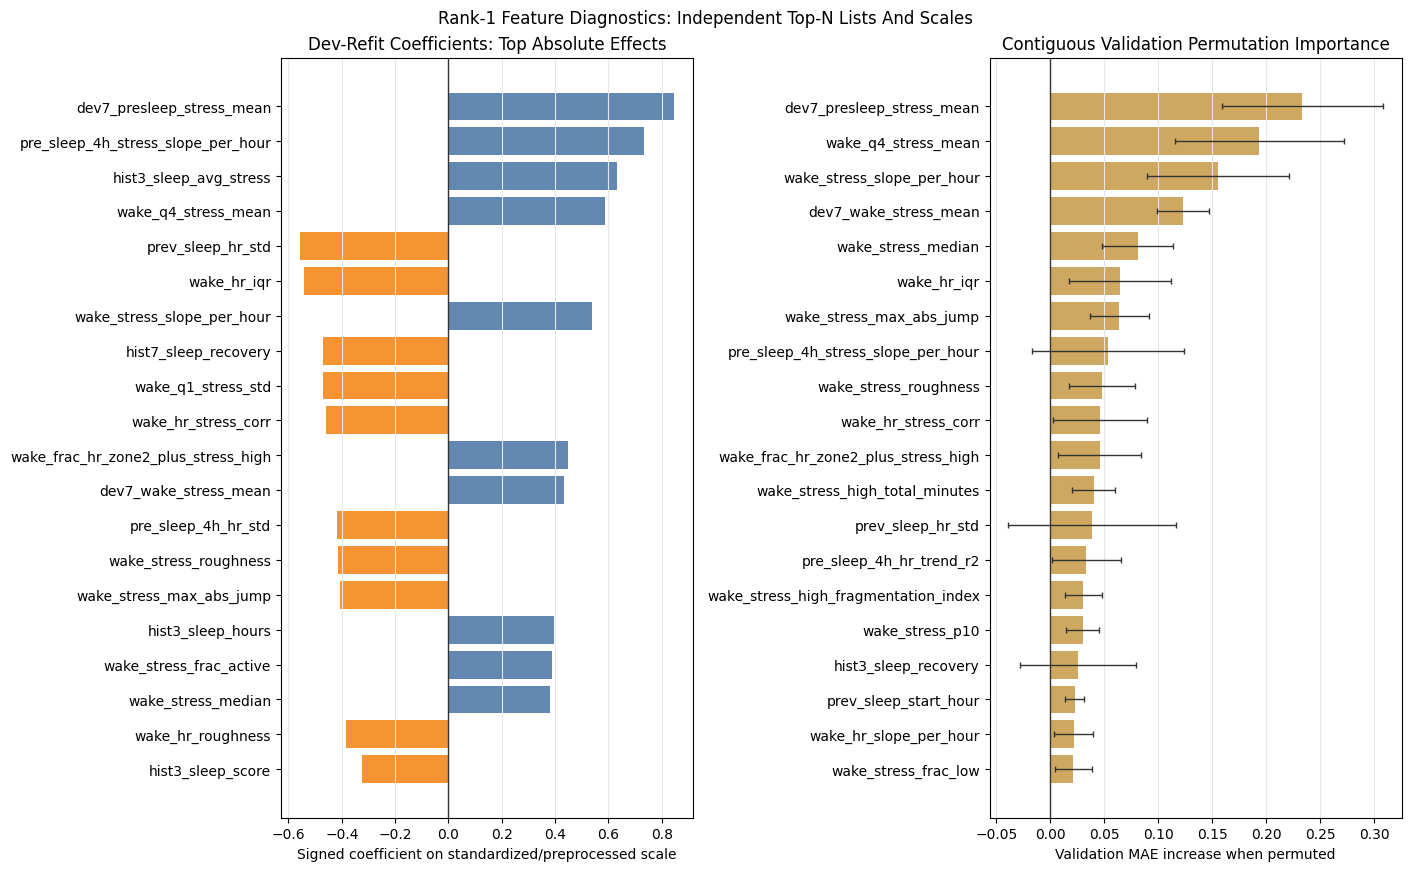

,feature,standardized_coefficient,abs_standardized_coefficient,transformed_feature_count,coefficient_available,permutation_mae_increase_mean,permutation_mae_increase_std,final_refit_selected,validation_fit_selected,coefficient_fit_source,permutation_fit_source,permutation_eval_split,baseline_valid_mae,permutation_repeats,rank
0,dev7_presleep_stress_mean,0.846818,0.846818,1.0,True,0.233535,0.074730,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,1
1,wake_q4_stress_mean,0.587788,0.587788,1.0,True,0.193846,0.078341,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,2
2,wake_stress_slope_per_hour,0.539951,0.539951,1.0,True,0.155446,0.065376,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,3
3,dev7_wake_stress_mean,0.433137,0.433137,1.0,True,0.122928,0.024426,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,4
4,wake_stress_median,0.382672,0.382672,1.0,True,0.080921,0.032871,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,5
5,wake_hr_iqr,-0.540315,0.540315,1.0,True,0.065027,0.047243,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,6
6,wake_stress_max_abs_jump,-0.406675,0.406675,1.0,True,0.063905,0.027313,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,7
7,pre_sleep_4h_stress_slope_per_hour,0.734043,0.734043,1.0,True,0.053375,0.070255,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,8
8,wake_stress_roughness,-0.414462,0.414462,1.0,True,0.048170,0.030606,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,9
9,wake_hr_stress_corr,-0.457447,0.457447,1.0,True,0.046296,0.043483,True,True,final_refit_pretest,train_split_model,valid,4.145302,10,10


feature_importance: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_rank1_feature_importance.csv
feature_importance_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_feature_importance.png


In [53]:
rank1_record = (
    result.leaderboard.loc[result.leaderboard["candidate_type"].eq("linear_family")]
    .sort_values("selection_rank")
    .iloc[0]
    .to_dict()
)
rank1_candidate = stage4_linear_candidate_from_record(rank1_record)
rank1_feature_importance = compute_stage4_linear_feature_importance(
    selection_tuning_result.splits,
    selection_tuning_result.feature_columns,
    rank1_candidate,
    config=selection_tuning_result.config,
    permutation_repeats=10,
    random_state=REPEATED_HOLDOUT_SEED,
)
rank1_feature_importance.to_csv(feature_importance_path, index=False)
importance_fig = plot_stage4_linear_rank1_feature_importance(
    rank1_feature_importance,
    top_n=20,
    save_path=feature_importance_figure_path,
)
display(importance_fig)
plt.close(importance_fig)
display(rank1_feature_importance.head(20))
print("feature_importance:", feature_importance_path)
print("feature_importance_figure:", feature_importance_figure_path)


## Public Artifacts


In [54]:
summary_text = build_stage4_linear_summary_markdown(result)
summary_path.write_text(summary_text, encoding="utf-8")
result.leaderboard.to_csv(leaderboard_path, index=False)
result.candidate_grid.to_csv(grid_path, index=False)

best_by_model_family = build_stage4_linear_best_by_model_family_artifact(
    result.leaderboard_slices["best_by_model_kind"],
    result.leaderboard_slices["dummy_baselines"],
    result.leaderboard,
)
best_by_model_family.to_csv(best_by_model_family_path, index=False)

print("summary:", summary_path)
print("leaderboard:", leaderboard_path)
print("grid:", grid_path)
print("best_by_model_family:", best_by_model_family_path)
print("feature_importance:", feature_importance_path)
print("diagnostic_figure:", diagnostic_figure_path)
print("feature_importance_figure:", feature_importance_figure_path)


summary: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_models_summary.md
leaderboard: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_model_leaderboard.csv
grid: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_model_grid.csv
best_by_model_family: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_best_by_model_family.csv
feature_importance: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_rank1_feature_importance.csv
diagnostic_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_prediction_diagnostics.png
feature_importance_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_feature_importance.png


/Users/abatrakov/Documents/FUN/wearable-analytics/src/garmin_analytics/modeling/stage4_linear.py:3994: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  keyed_leaderboard = leaderboard.assign(


## Final Read

Use the Stage 1 diagnostics to understand the full candidate grid, and the Stage 2 rerank to make the definitive validation-only selection. The global leader and model-family representatives are frozen before the future test is opened. After final refit, `dev` is an in-sample diagnostic and `test` is the only forward-looking readout.

The comparison baseline is `BASELINE_STRATEGY`, chosen before future-test evaluation. Other dummy test results remain useful diagnostics, but they do not change the declared baseline or the selected model.
